In [76]:
library(tidyverse)
library(MASS)
library(anndata)
library(pbapply)


# Set options

In [1]:
options(repr.plot.width = 15, repr.plot.height = 8)
set.seed(seed = 1)


# Load data

In [ ]:
adata <- read_h5ad("/mnt/weird_vol/projects/ifnb_nsc/5prime10x_2024/processing/Ifit1KO_WT_young_old_10x_processed.h5ad")
adata


AnnData object with n_obs × n_vars = 8799 × 2500
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'HTO_maxID', 'HTO_secondID', 'HTO_margin', 'HTO_classification', 'HTO_classification.global', 'hash.ID', 'cell_barcode', 'genotype', 'tissue', 'mouse', 'sample', 'hto_success', 'percent.mt', 'Sample', 'Genotype', 'Age', 'Region', 'HTO', 'batch', 'n_genes', 'doublet_score', 'predicted_doublet', 'n_counts', 'S_score', 'G2M_score', 'phase', 'age_global'
    var: 'gene_ids', 'feature_types', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'Age_colors', 'Genotype_colors', 'HTO_classification.global_colors', 'HTO_colors', 'Region_colors', 'Sample_colors', 'age_global_colors', 'batch_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'phase_colors', 'scrublet', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'lognorm'
    obsp: 'connectivities', 'distances'

In [ ]:
adata$X <- adata$layers["lognorm"]


# Check data properties

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  230.6   469.5   527.0   533.8   584.8   963.3 

CCTTCGAAGCCAGGAT-1 
              1349

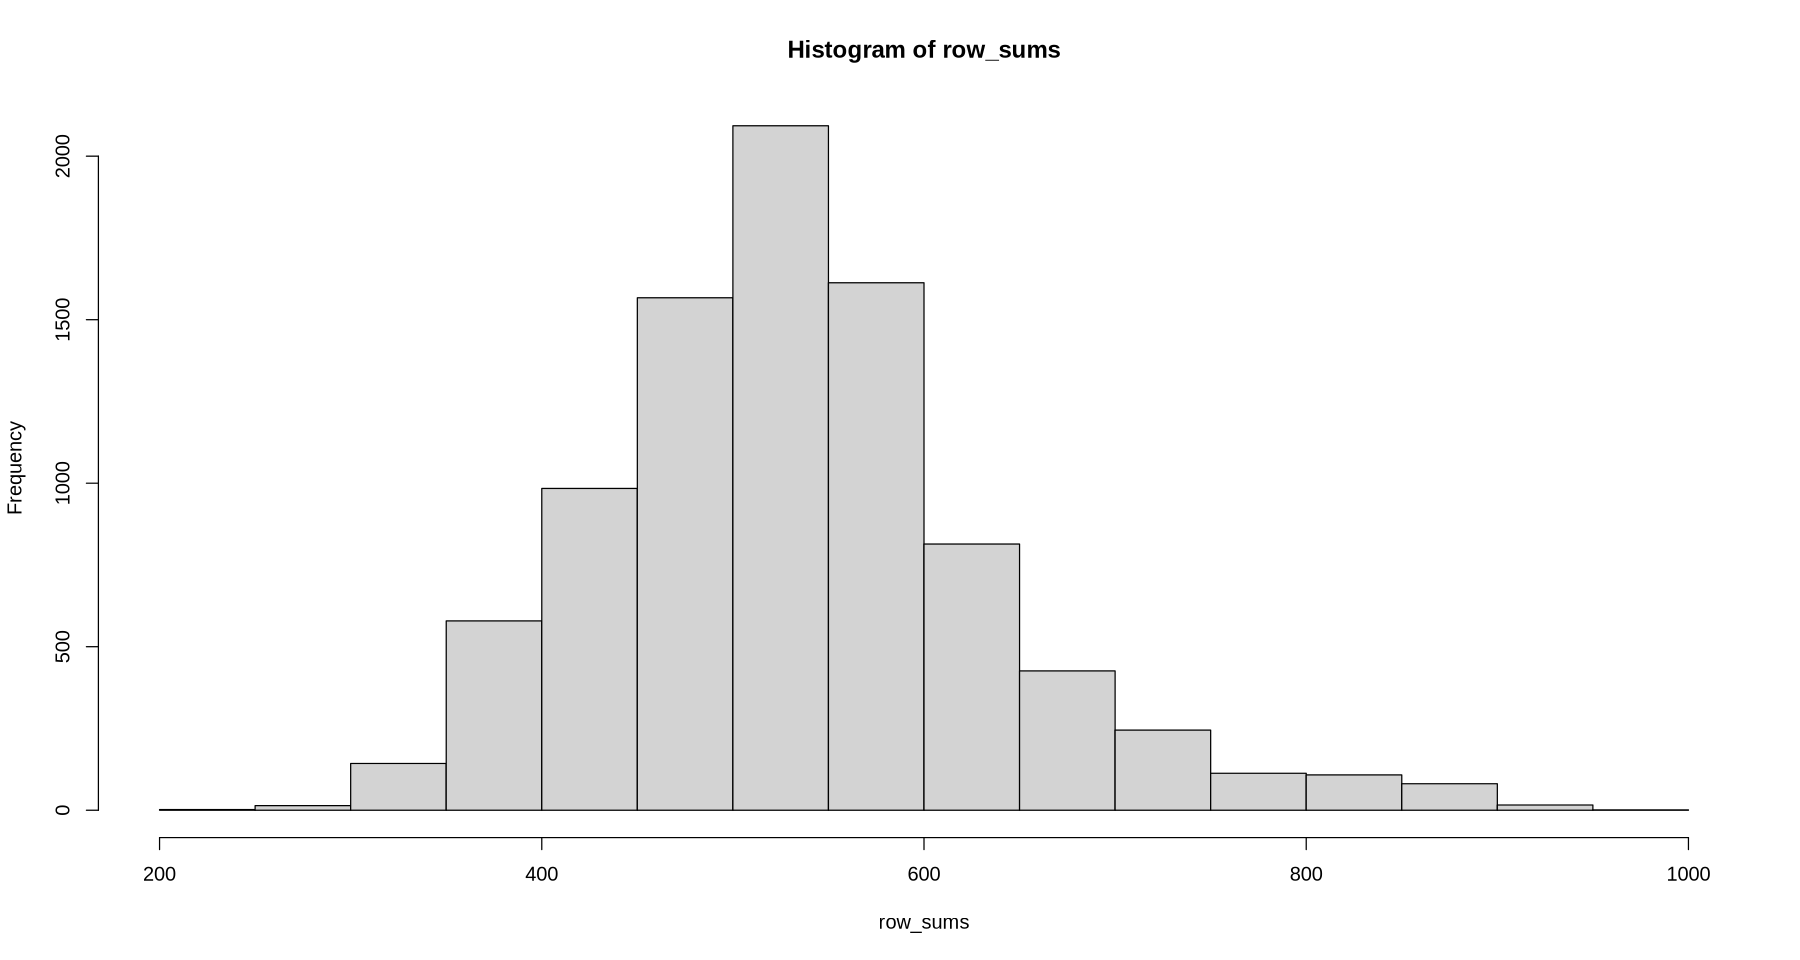

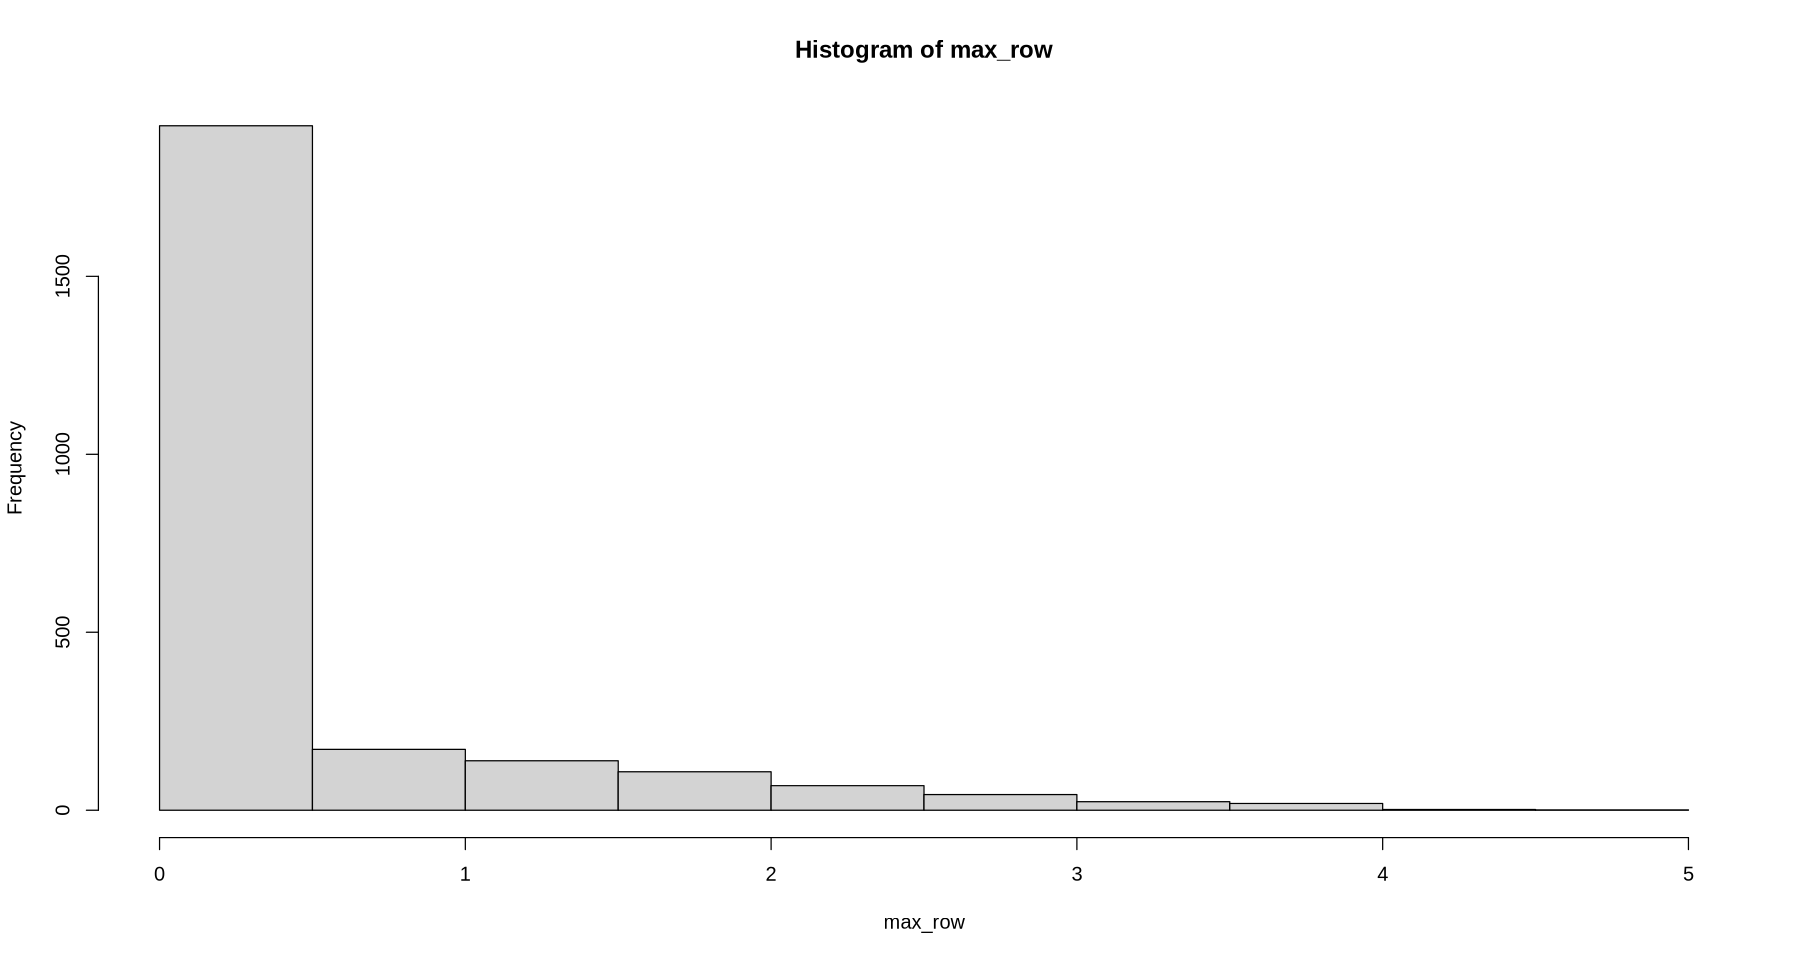

In [87]:
# Calculate row sums
row_sums <- rowSums(as.matrix(adata$X))
hist(row_sums)

# Summary statistics of row sums
summary(row_sums)

# Get the row with the maximum sum value
max_row_index <- which.max(row_sums)
max_row <- adata$X[max_row_index, ]
max_row_index
hist(max_row)


     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
    1.246    30.364   585.660  1878.663  2296.393 30695.965 

Cst3 
 338

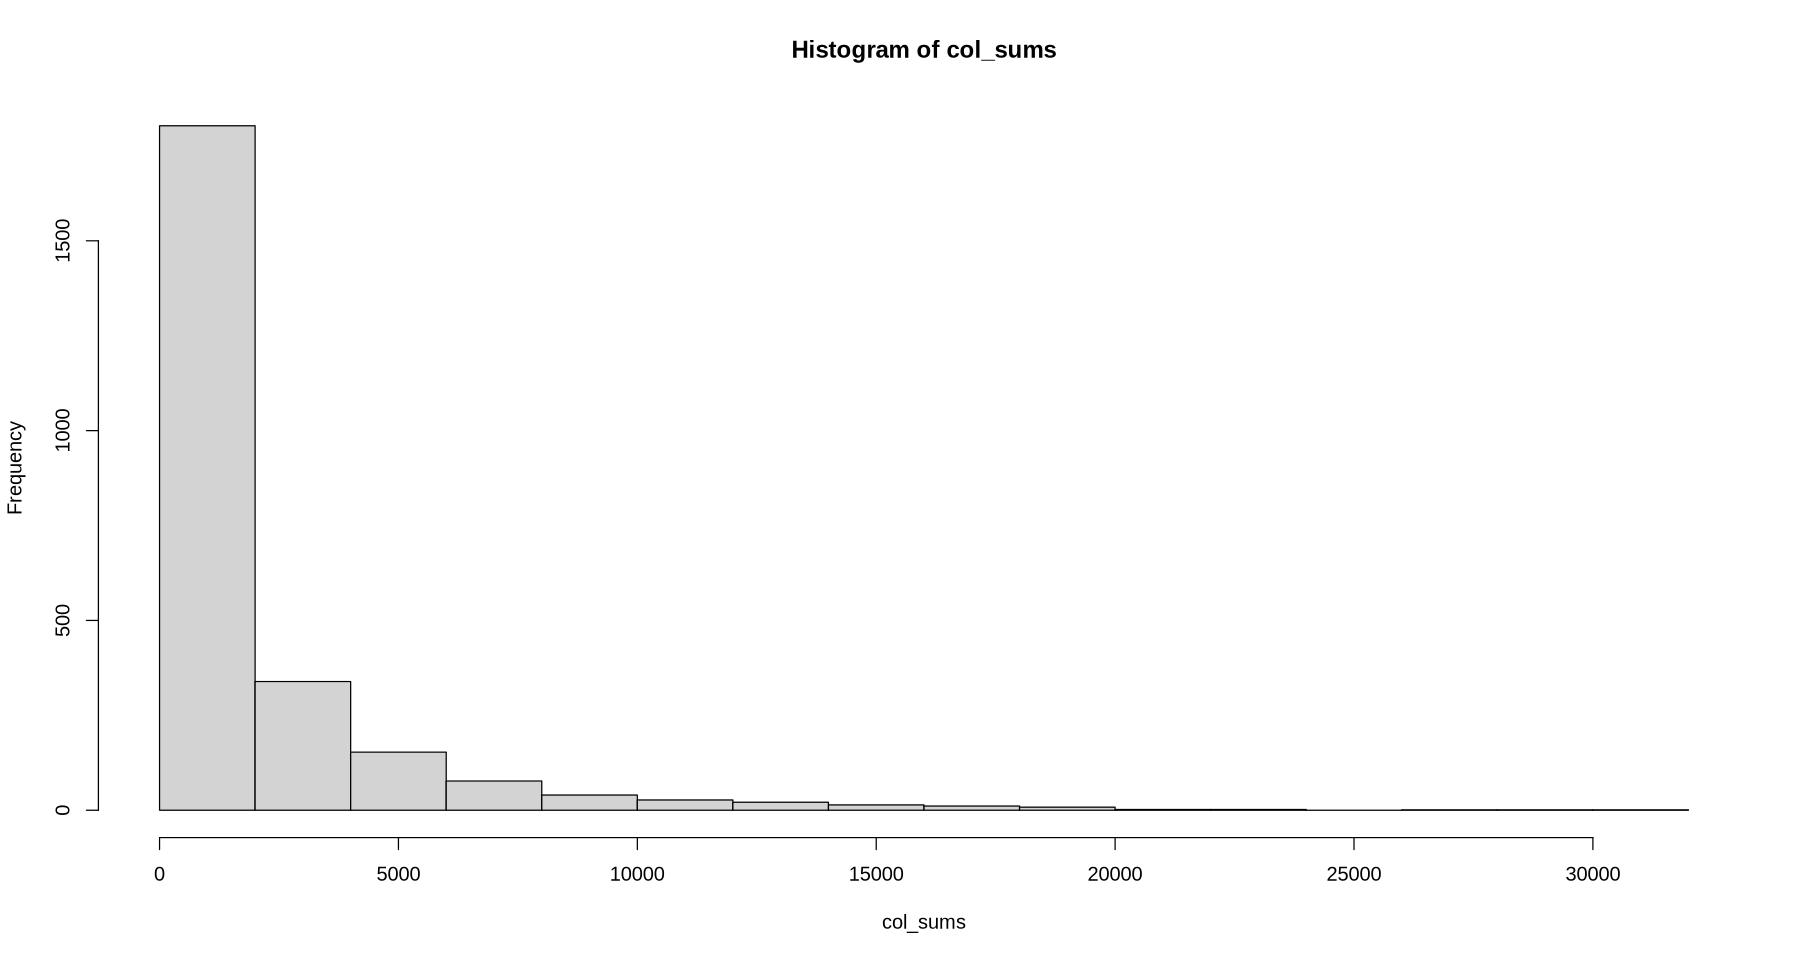

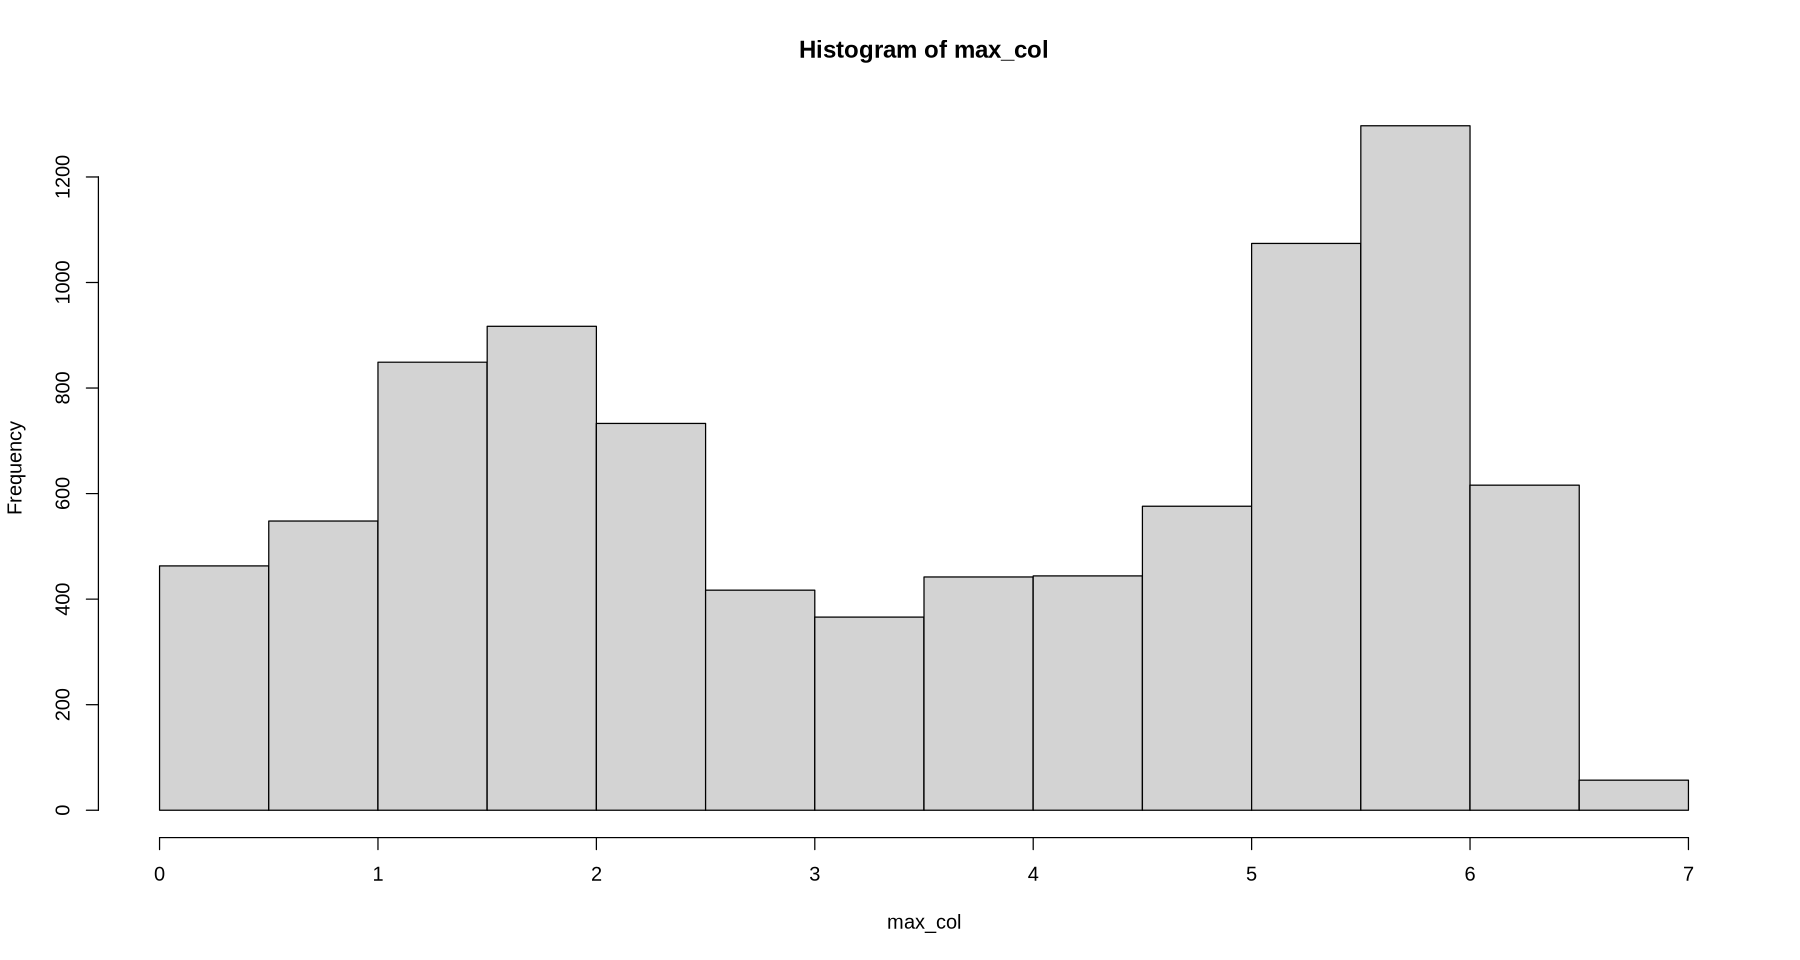

In [88]:
# Calculate row sums
col_sums <- colSums(as.matrix(adata$X))
hist(col_sums)

# Summary statistics of row sums
summary(col_sums)

# Get the row with the maximum sum value
max_col_index <- which.max(col_sums)
max_col <- adata$X[, max_col_index]
max_col_index
hist(max_col)


# Simulating one gene

## Unimodal data

### Poisson

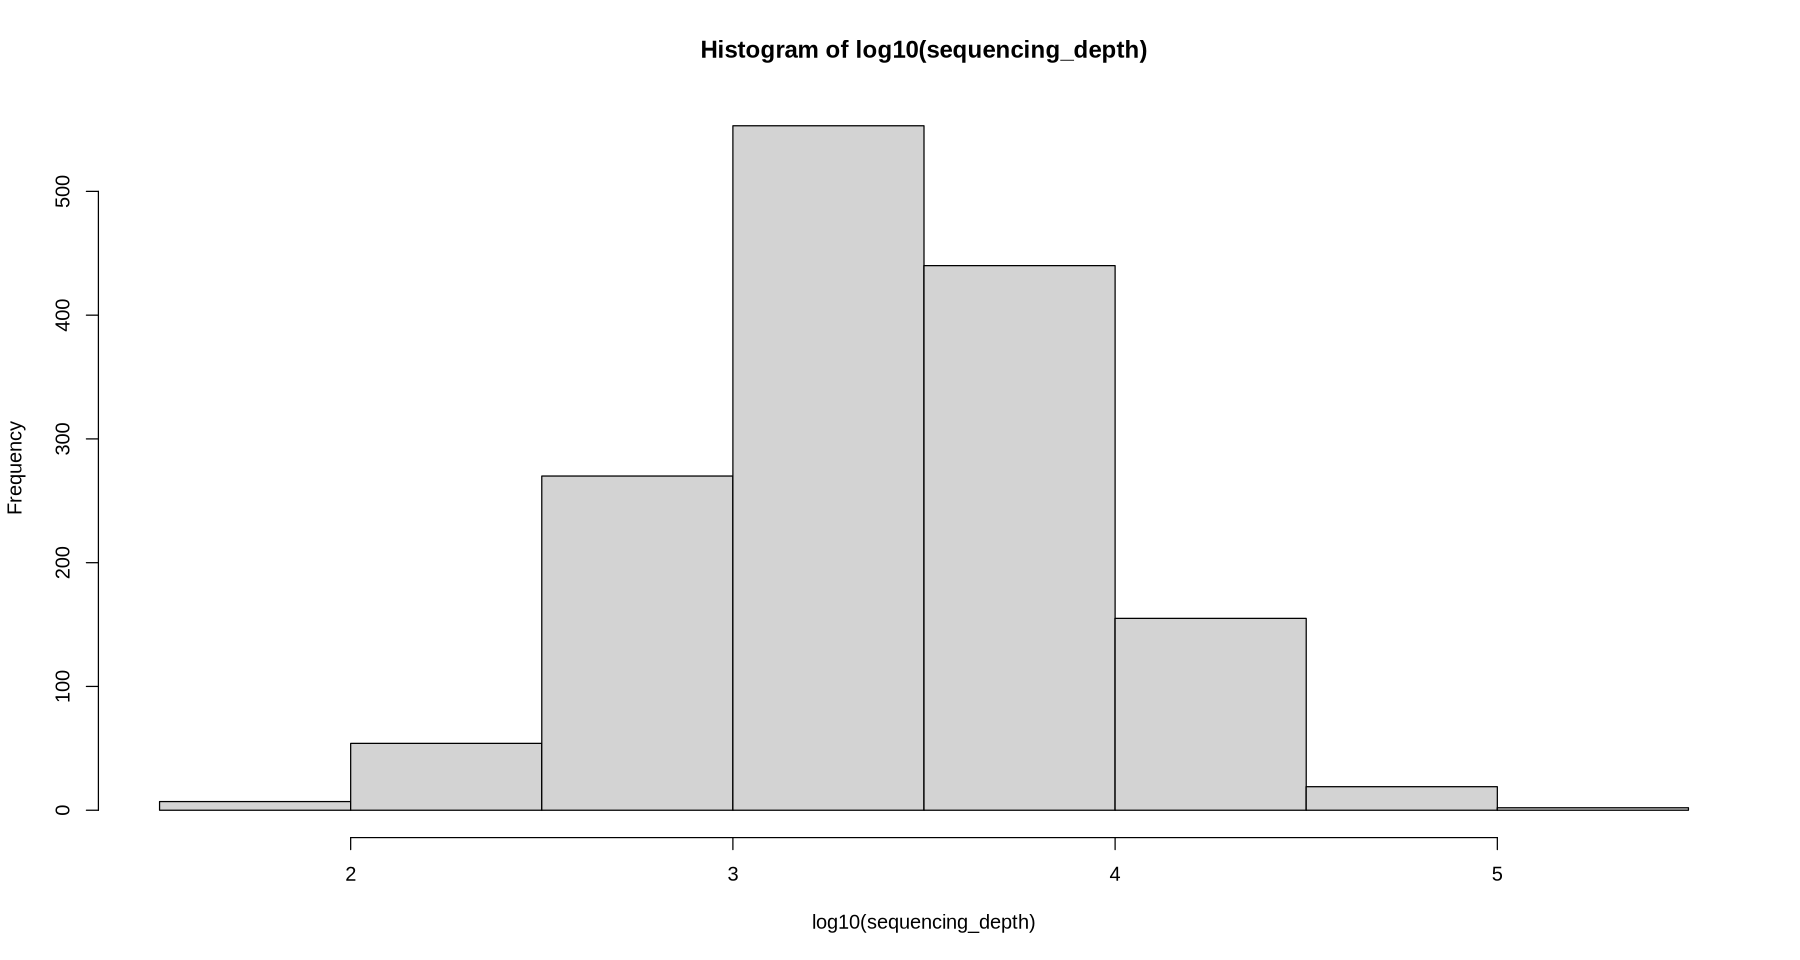

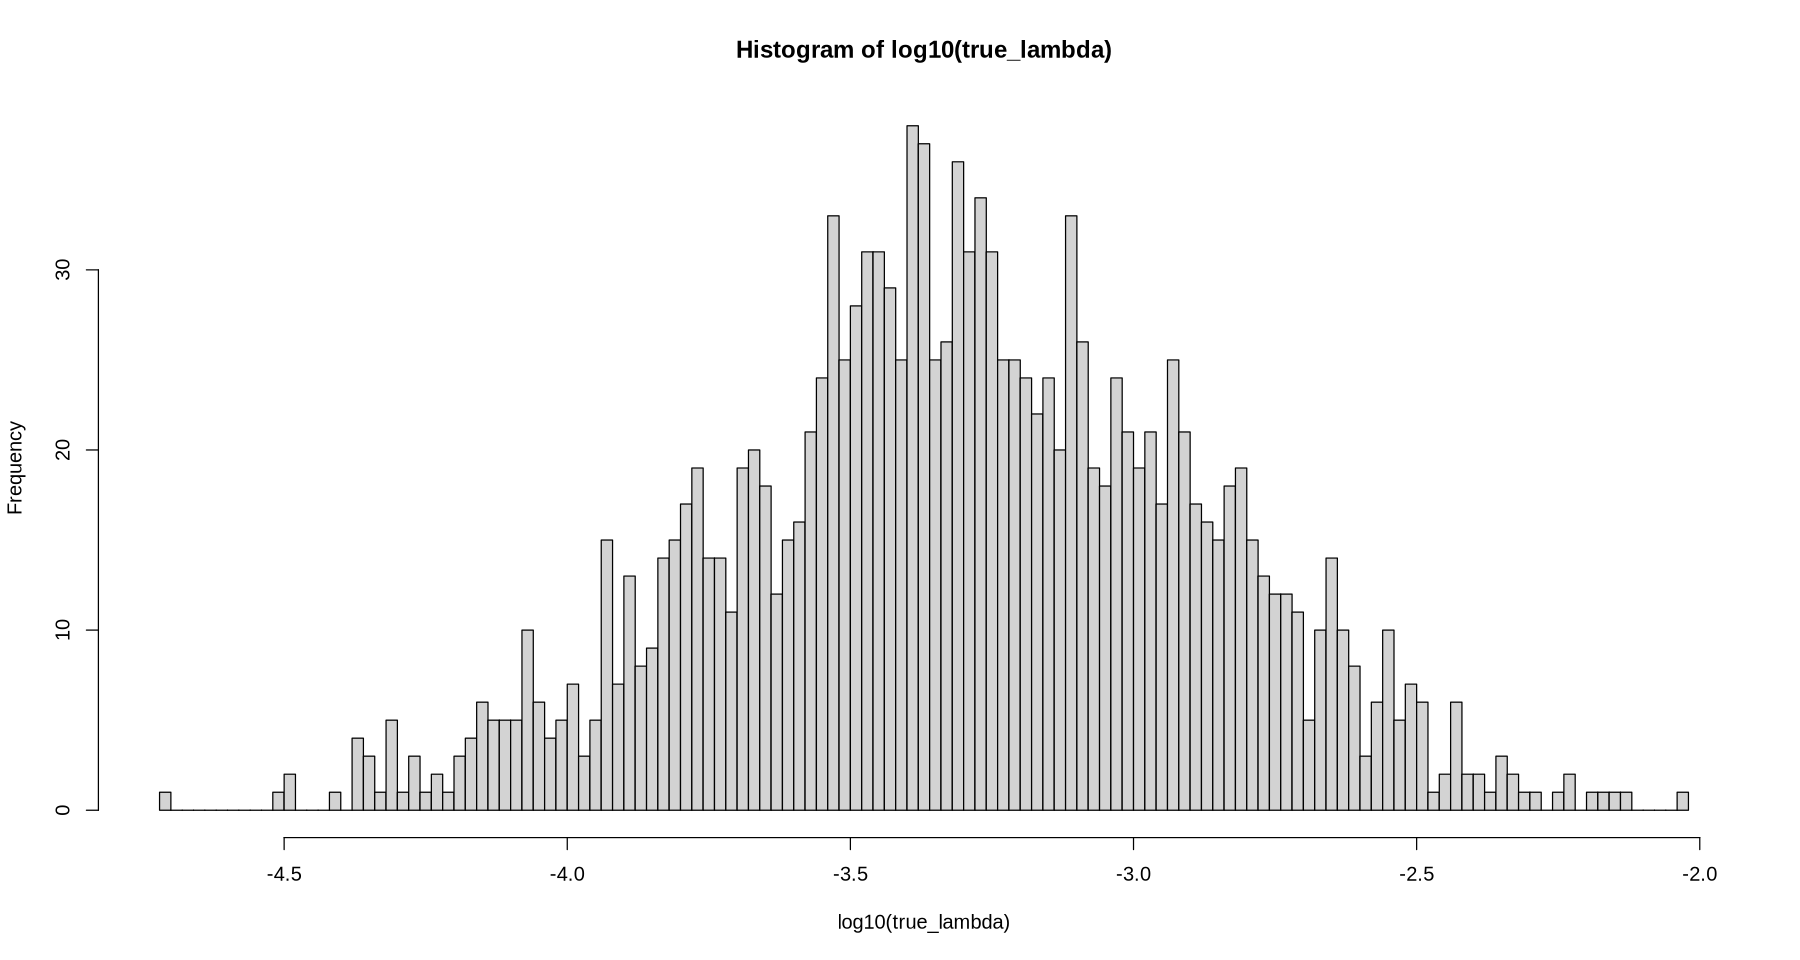

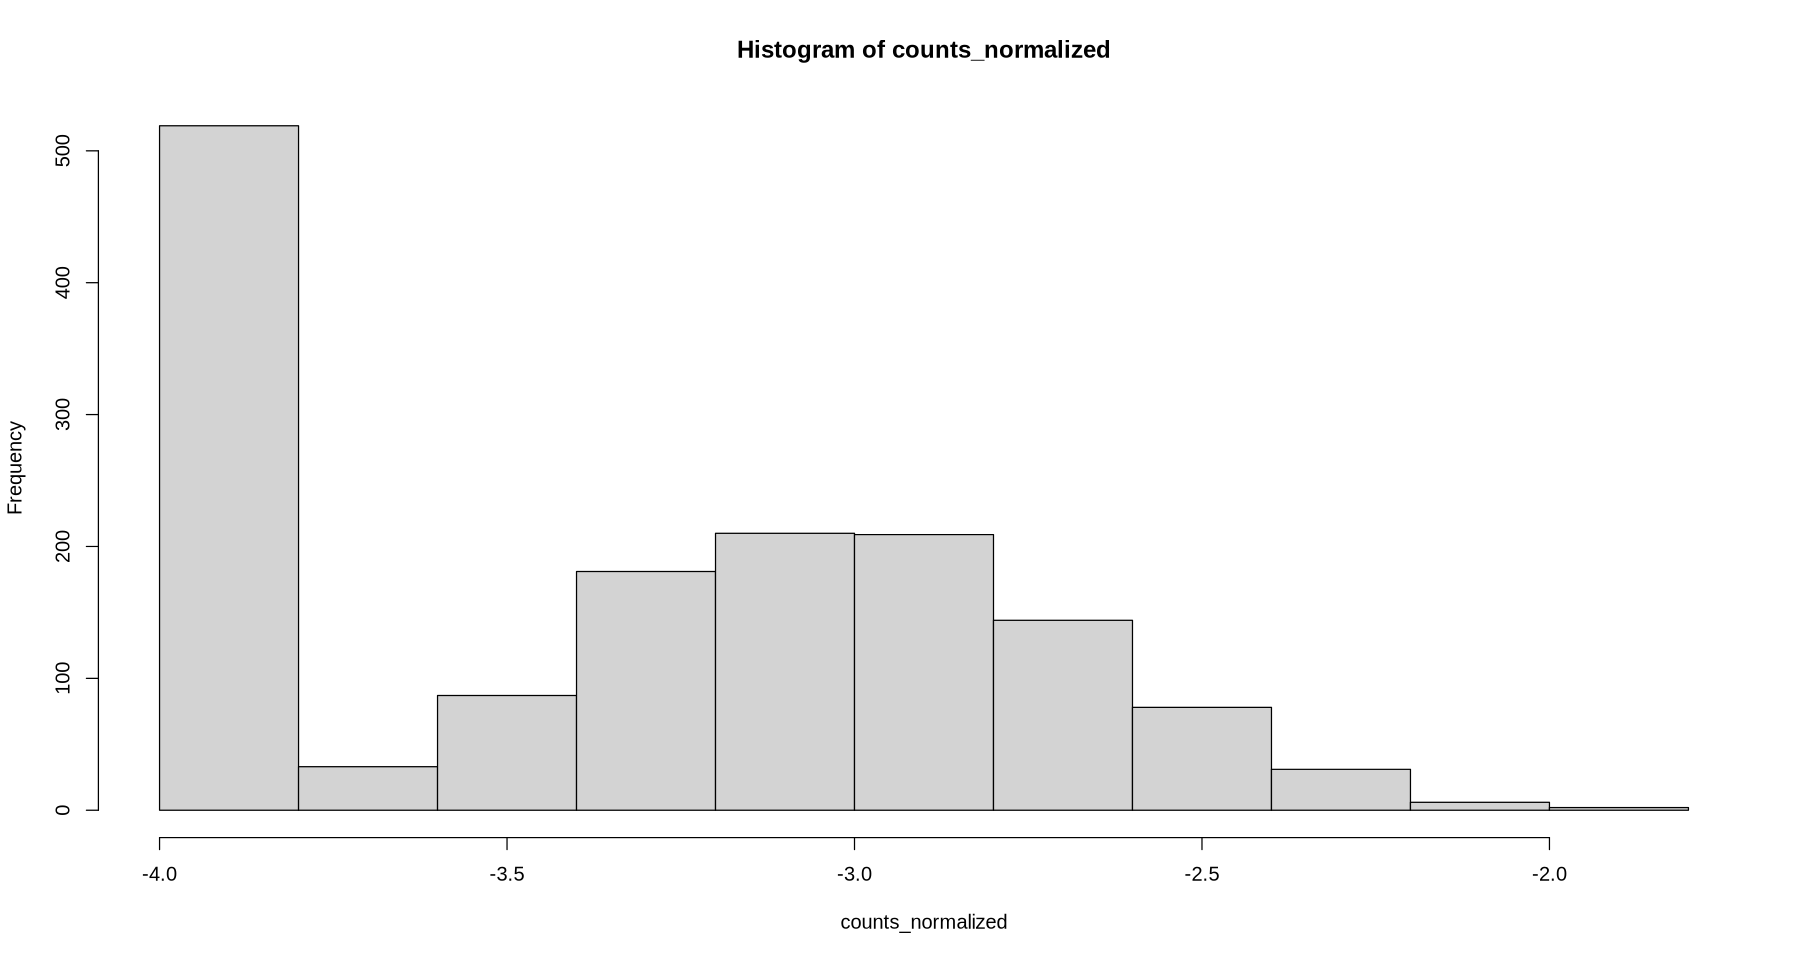

In [ ]:
# Number of cells to simulate
n <- 1500

# Get log-normally distributed total number of RNA molecules sequenced per cell (library size or sequencing depth)
# Log-normal guarantees non-negative counts and a tapering down in density for higher counts
# We first set average library size and standard deviation
mean_size <- 2500
std_size <- 0.5
sequencing_depth <- round(10^rnorm(n, log10(mean_size), std_size))
hist(log10(sequencing_depth))

# Simulate the true expression rate for each cell
mean_rate <- -3.3 # corresponds to expression rate around 10^(-3.3) = 0.0005
std_rate <- 0.4
true_lambda <- 10^rnorm(n, mean_rate, std_rate)
hist(log10(true_lambda), 100)

# Simulate the observed read counts per cell as a poisson process
# The expected count for each cell is proportional to the true expression rate and the sequencing depth
counts <- rpois(n, true_lambda * sequencing_depth)
# Normalize the expression counts per cell and log-transform them
counts_normalized <- log10(counts / sequencing_depth + 1e-4)
hist(counts_normalized)


### Negative binomial

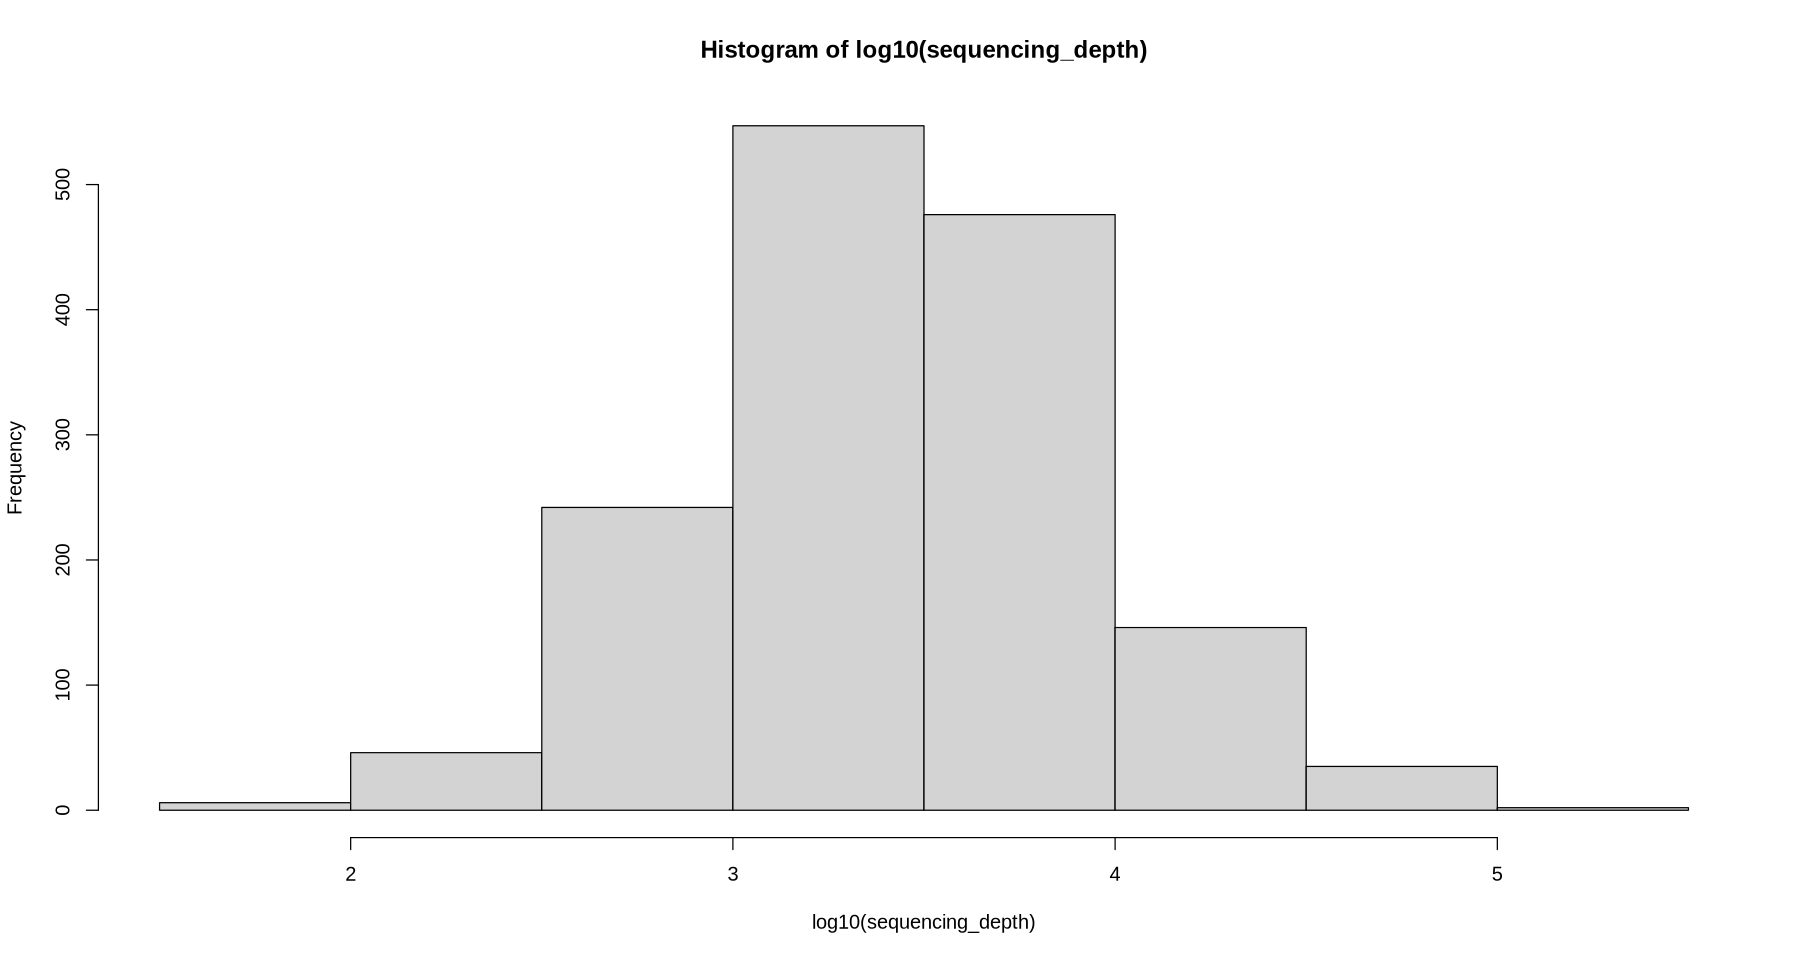

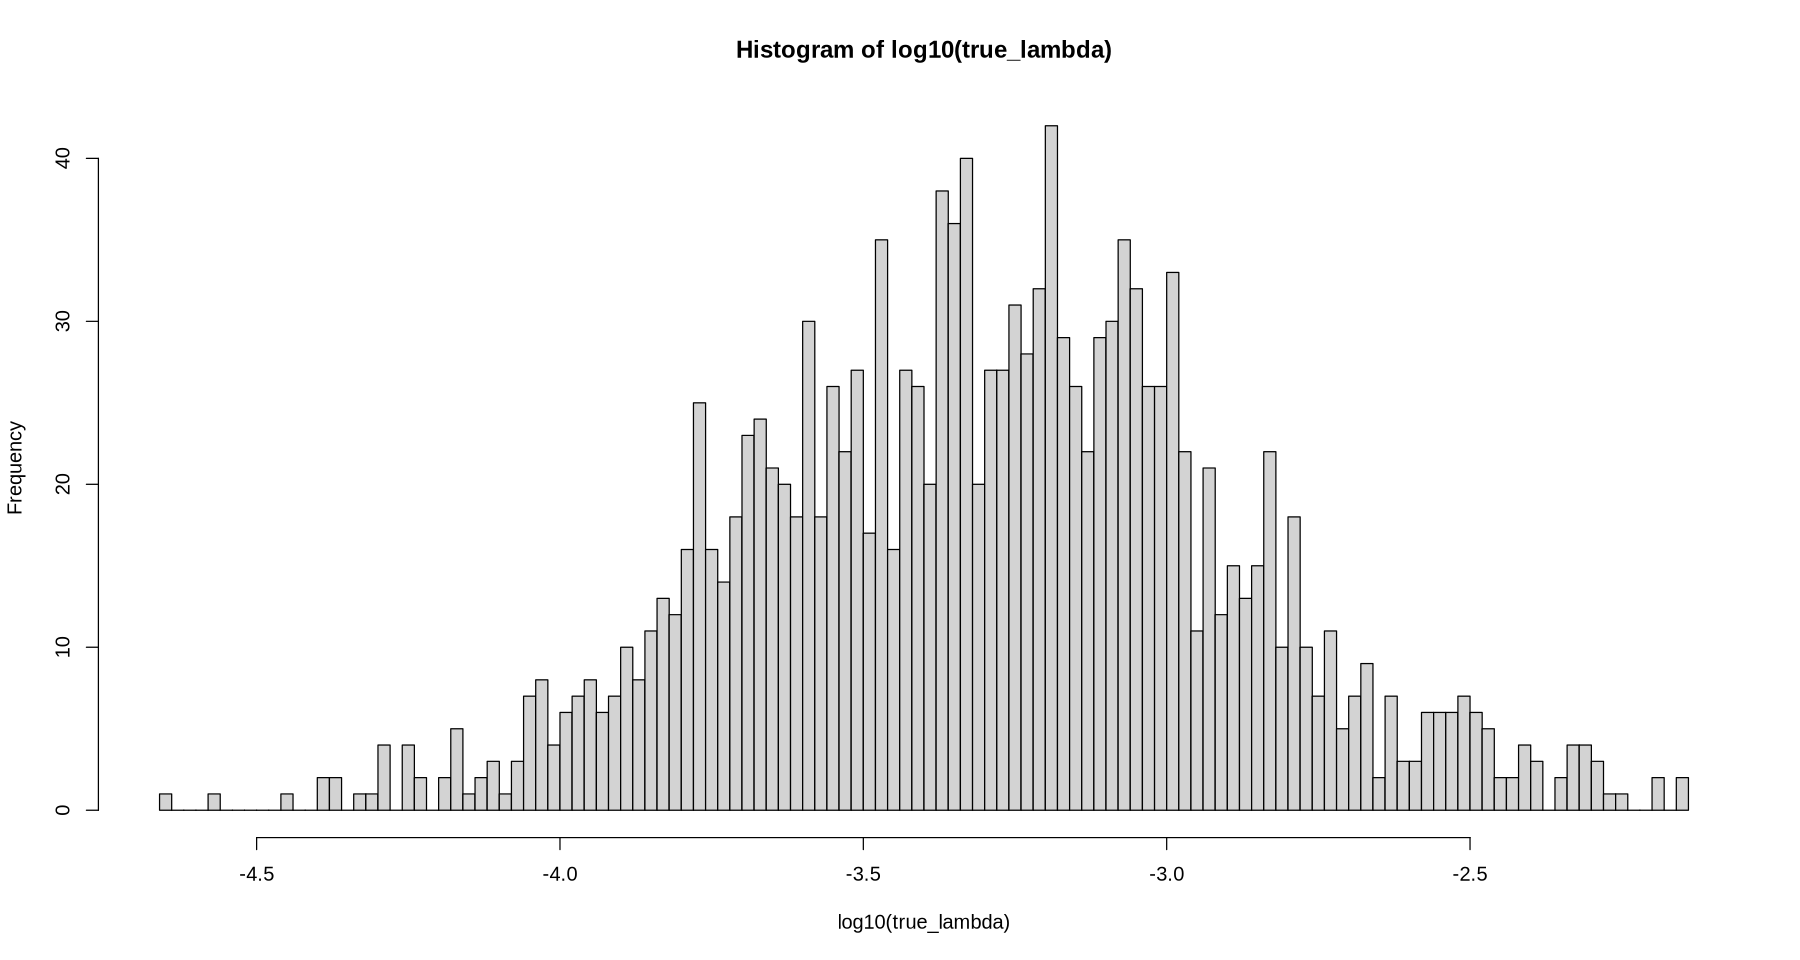

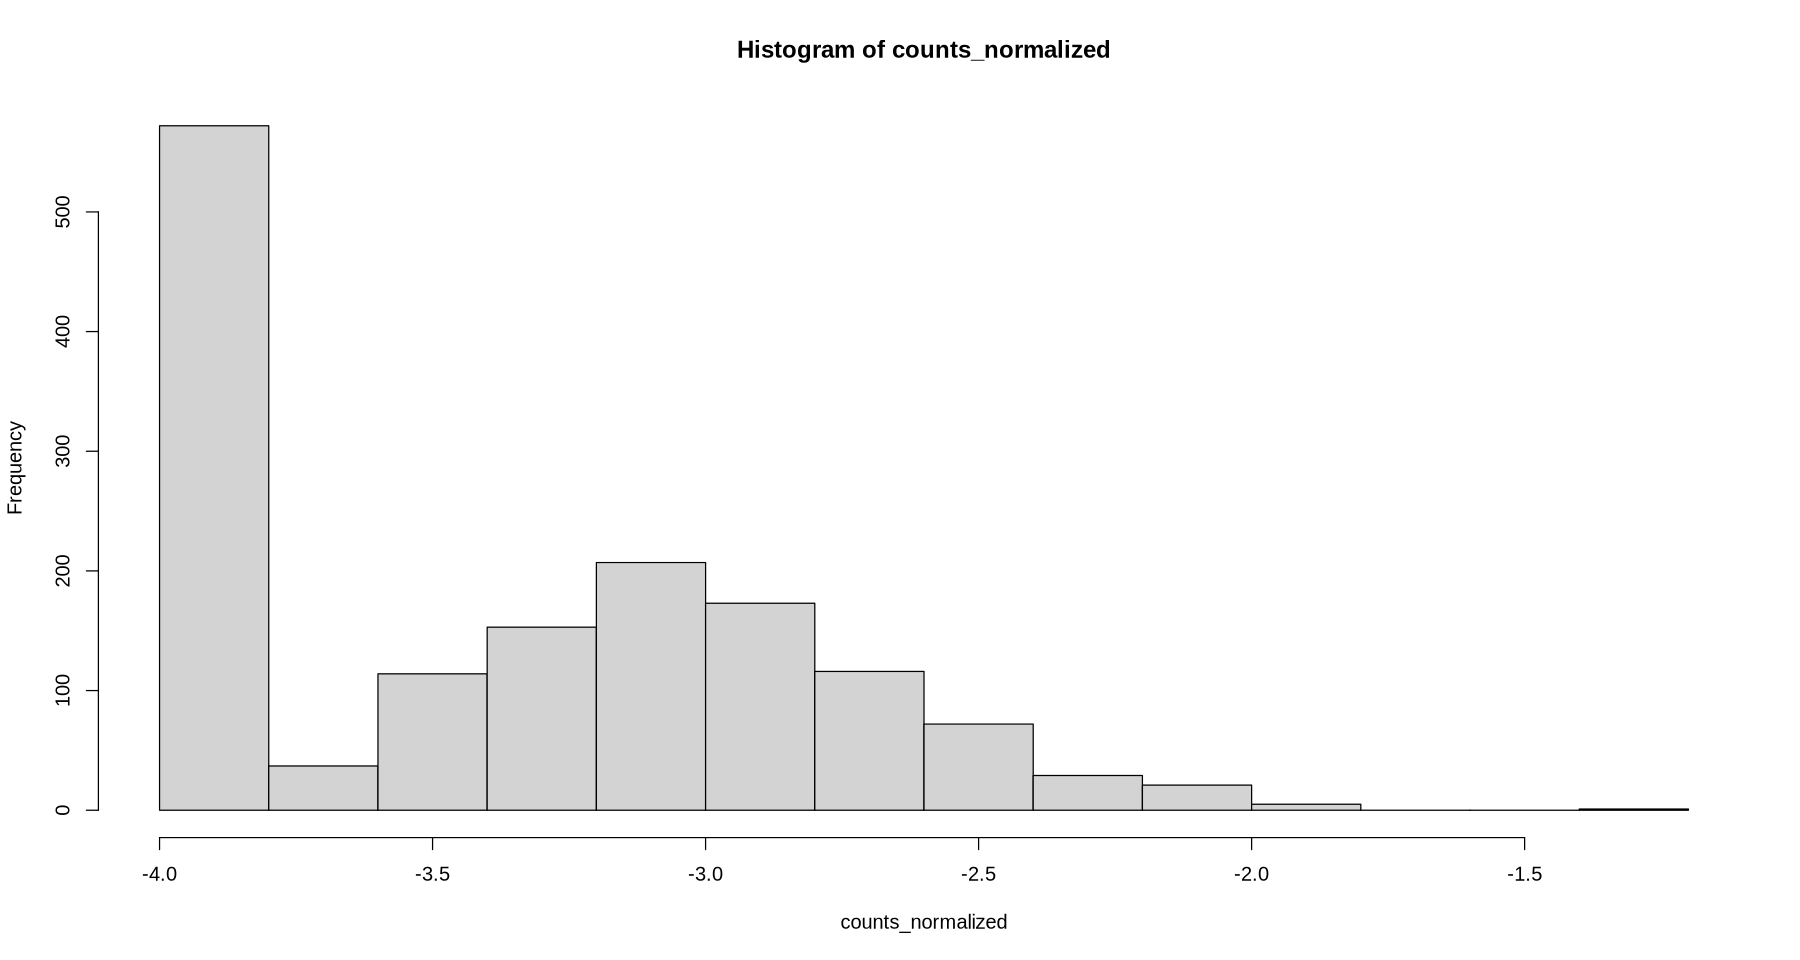

In [6]:
# Number of cells to simulate
n <- 1500

# Dispersion parameter
theta <- 3

# Get log-normally distributed total number of RNA molecules sequenced per cell (library size or sequencing depth)
# Log-normal guarantees non-negative counts and a tapering down in density for higher counts
# We first set average library size and standard deviation
mean_size <- 2500
std_size <- 0.5
sequencing_depth <- round(10^rnorm(n, log10(mean_size), std_size))
hist(log10(sequencing_depth))

# Simulate the true expression rate for each cell
mean_rate <- -3.3 # corresponds to expression rate around 10^(-3.3) = 0.0005
std_rate <- 0.4
true_lambda <- 10^rnorm(n, mean_rate, std_rate)
hist(log10(true_lambda), 100)

# Simulate the observed read counts per cell as a poisson process
# The expected count for each cell is proportional to the true expression rate and the sequencing depth
counts <- rnbinom(n, size = theta, mu = true_lambda * sequencing_depth)
# Normalize the expression counts per cell and log-transform them
counts_normalized <- log10(counts / sequencing_depth + 1e-4)
hist(counts_normalized)


## Bimodal data

### Poisson

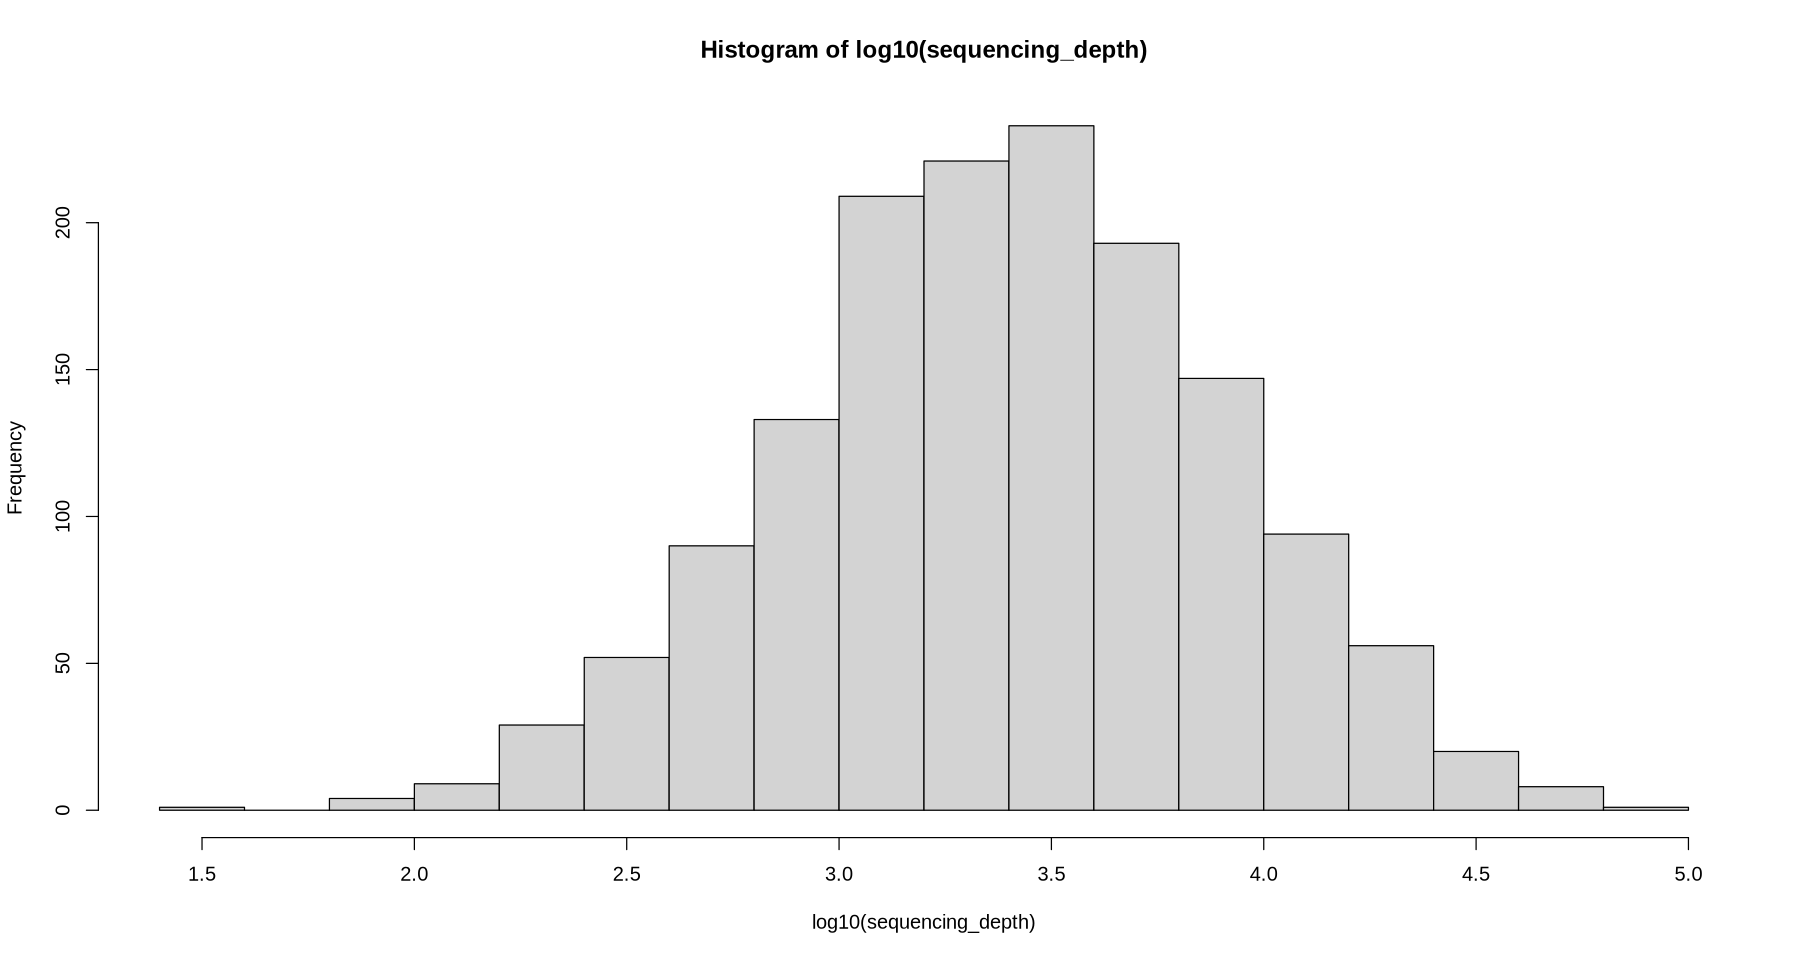

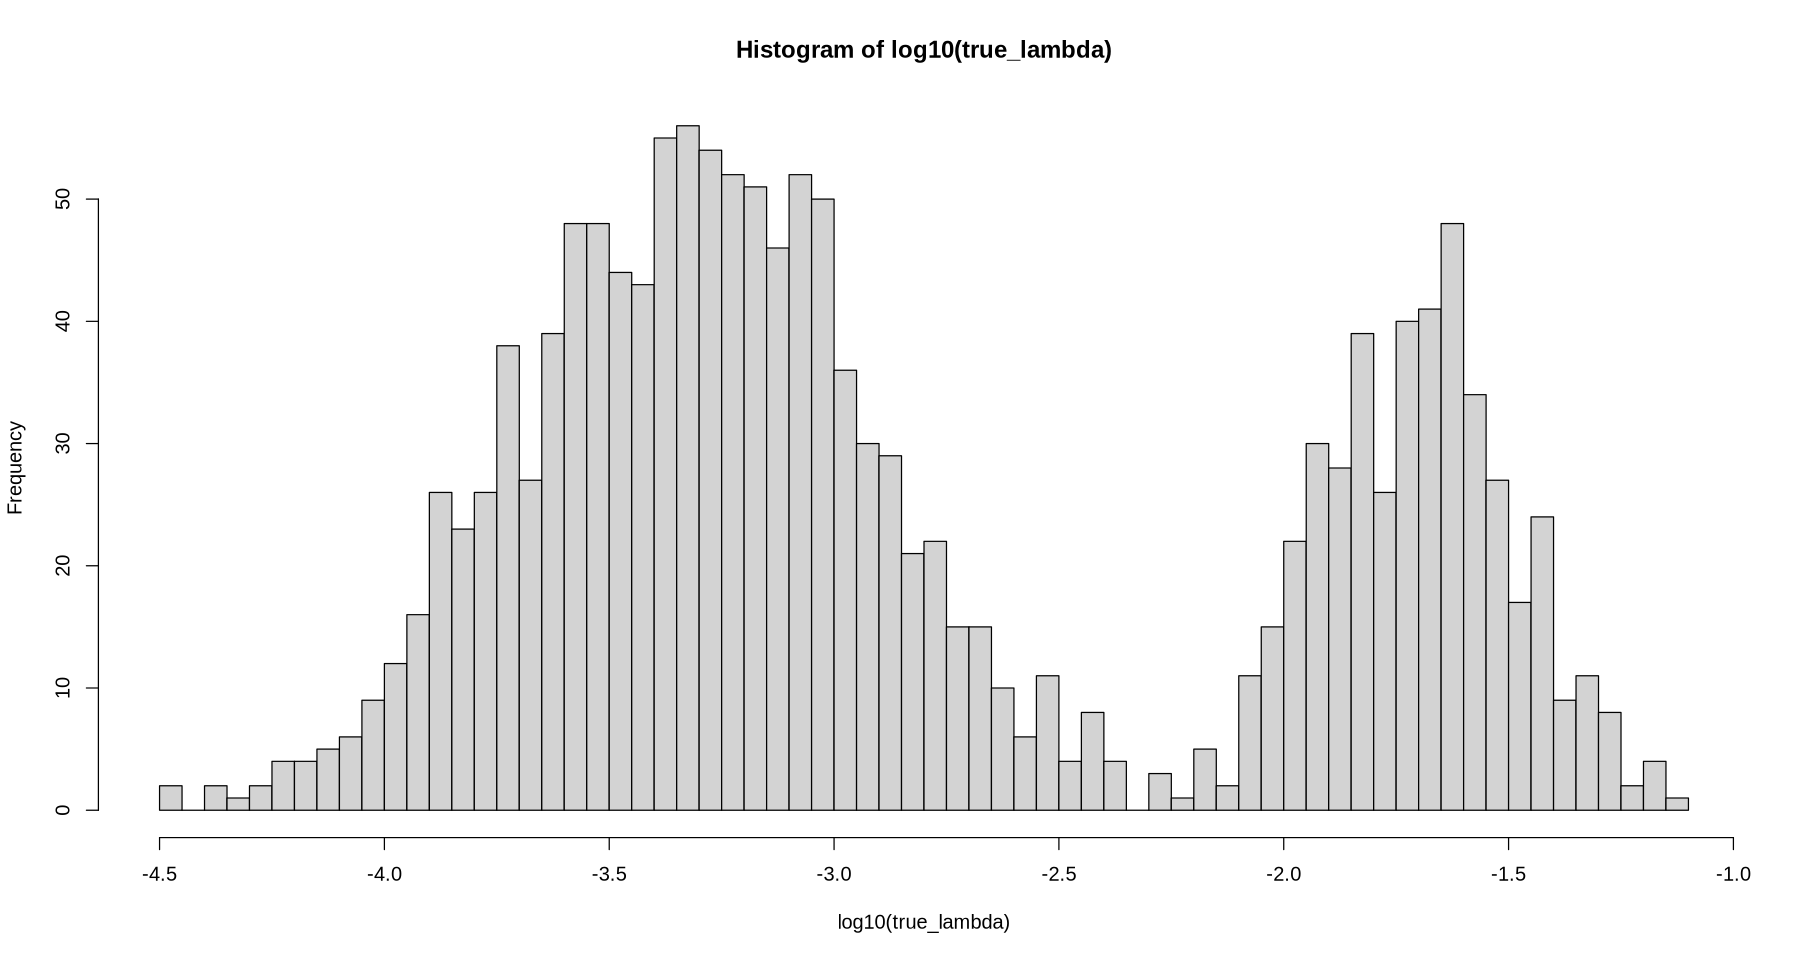

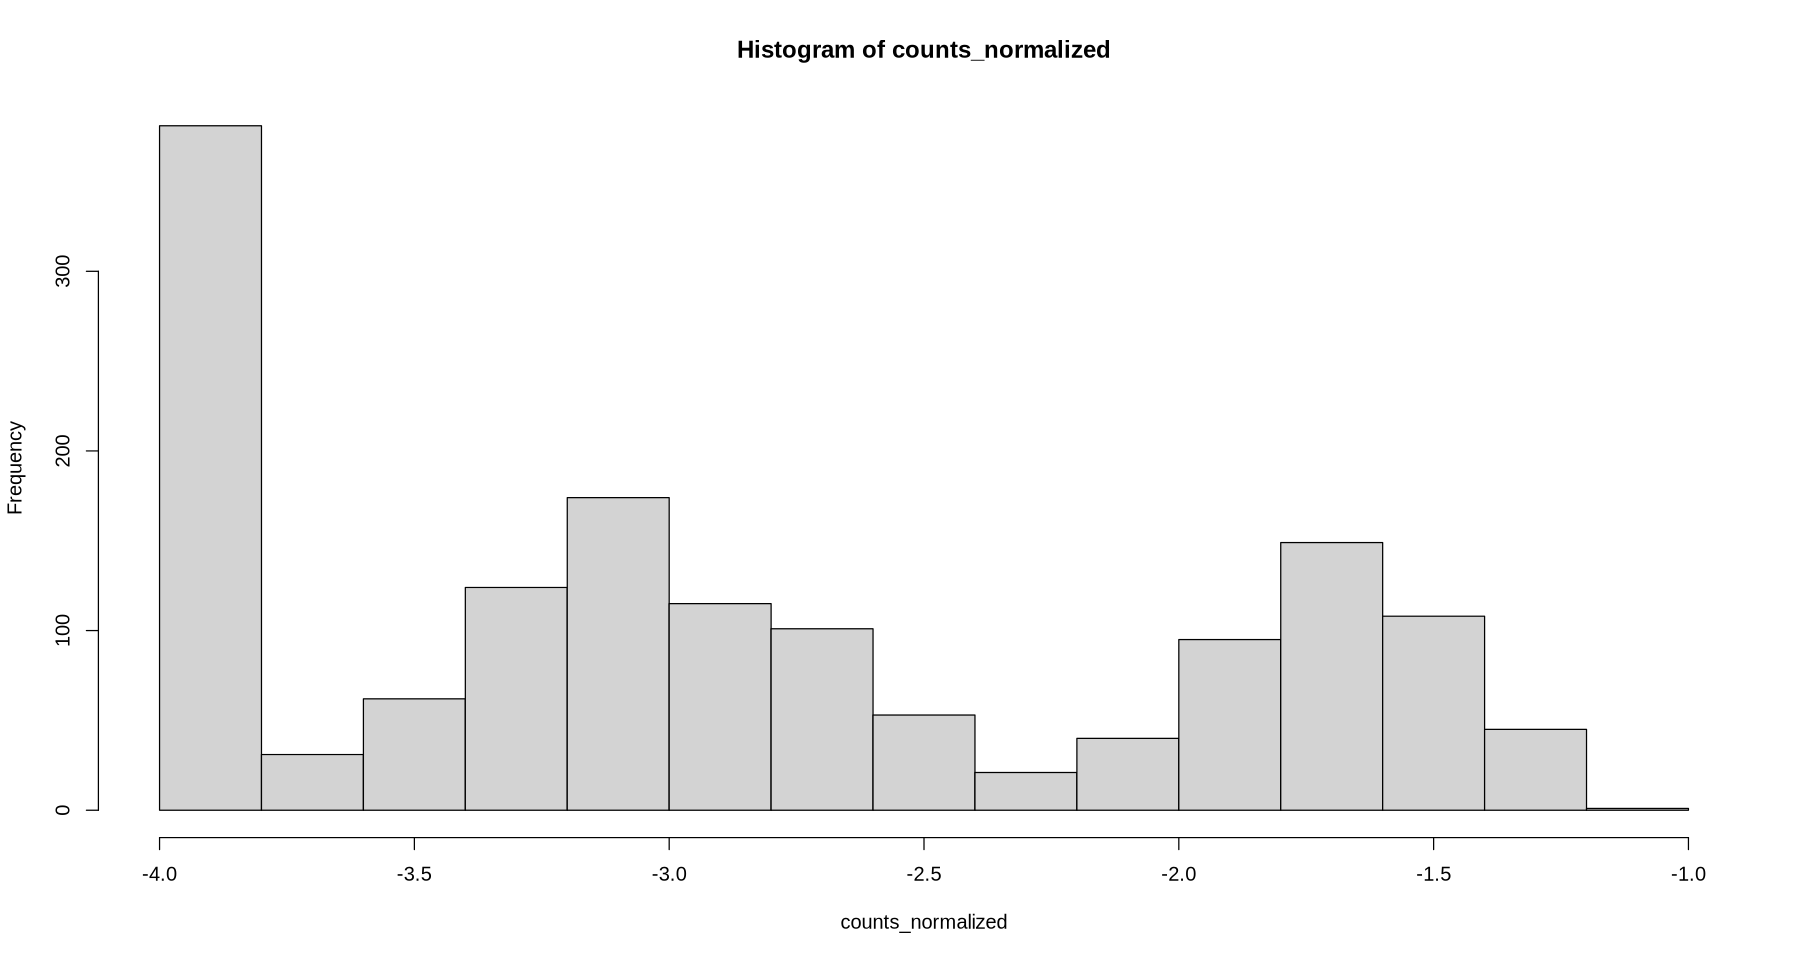

In [5]:
# Number of cells to simulate
n <- 1500

# Get log-normally distributed total number of RNA molecules sequenced per cell (library size or sequencing depth)
# Log-normal guarantees non-negative counts and a tapering down in density for higher counts
# We first set average library size and standard deviation
mean_size <- 2500
std_size <- 0.5
sequencing_depth <- round(10^rnorm(n, log10(mean_size), std_size))
hist(log10(sequencing_depth))

# Simulate the true expression rate for each cell
mean_rate <- -3.3 # corresponds to expression rate around 10^(-3.3) = 0.0005
std_rate <- 0.4
mean_rate_2 <- -1.7
std_rate_2 <- 0.2
true_lambda <- 10^ifelse(runif(n) < .7, rnorm(n, mean_rate, std_rate), rnorm(n, mean_rate_2, std_rate_2))
hist(log10(true_lambda), 100)

# Simulate the observed read counts per cell as a poisson process
# The expected count for each cell is proportional to the true expression rate and the sequencing depth
counts <- rpois(n, true_lambda * sequencing_depth)
# Normalize the expression counts per cell and log-transform them
counts_normalized <- log10(counts / sequencing_depth + 1e-4)
hist(counts_normalized)


### Negative binomial

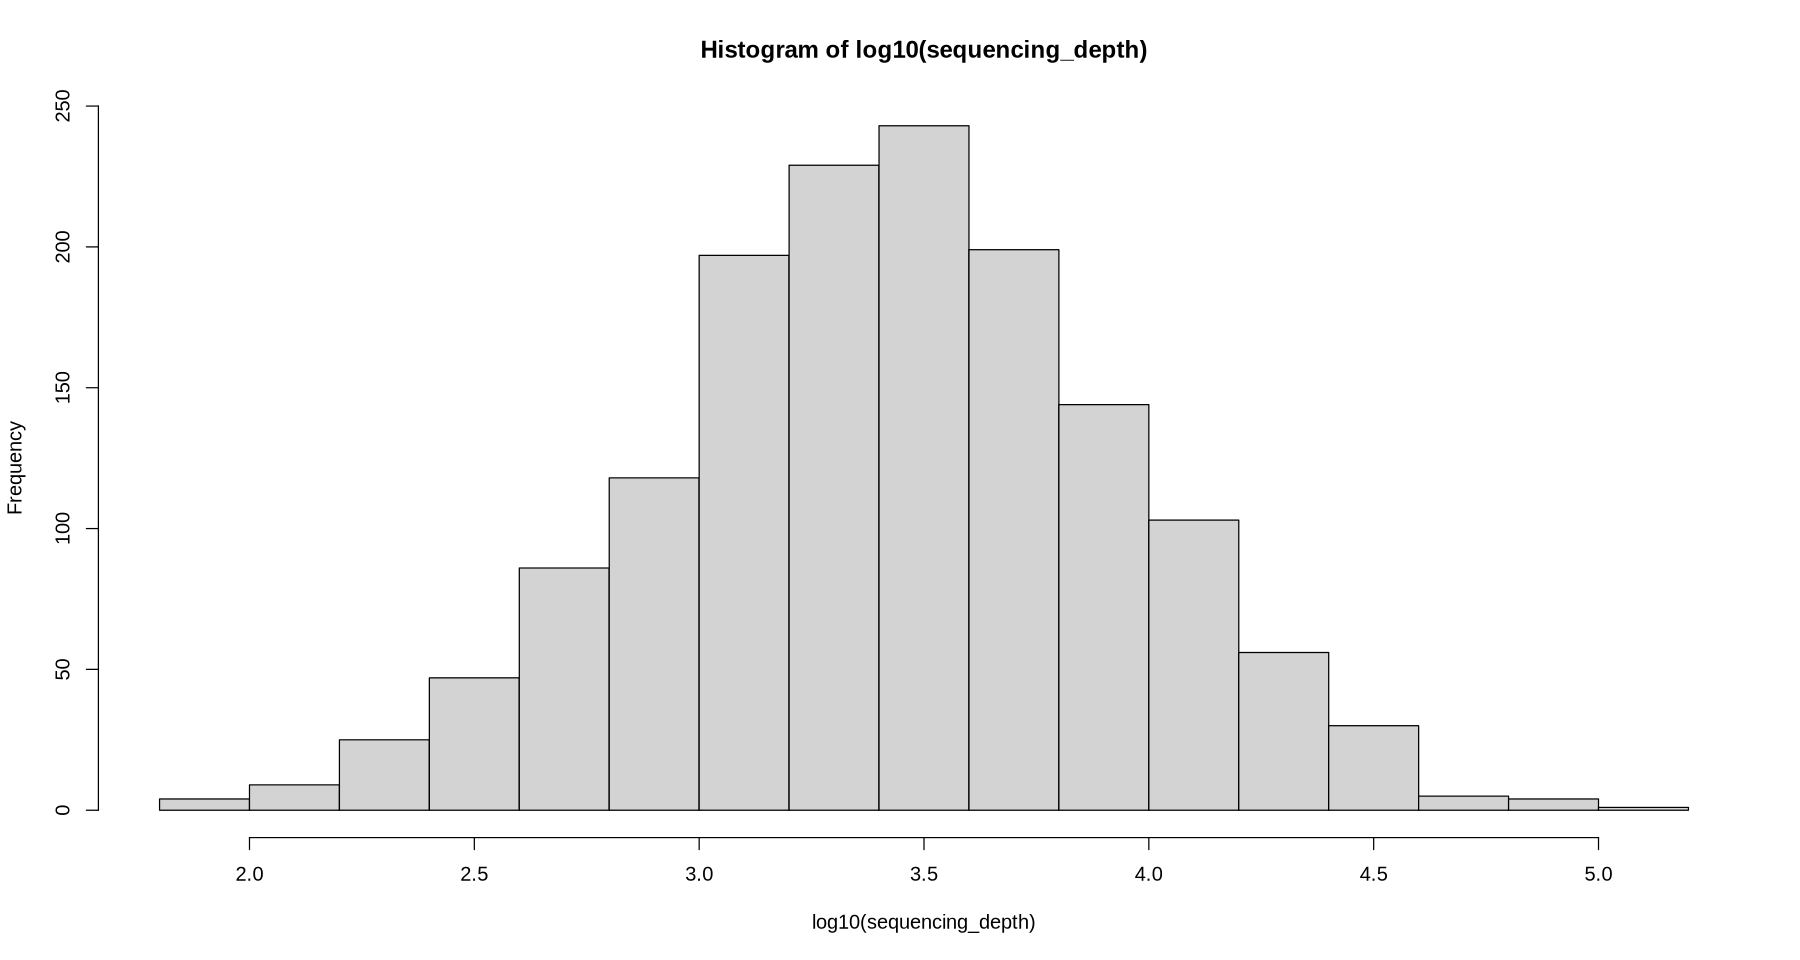

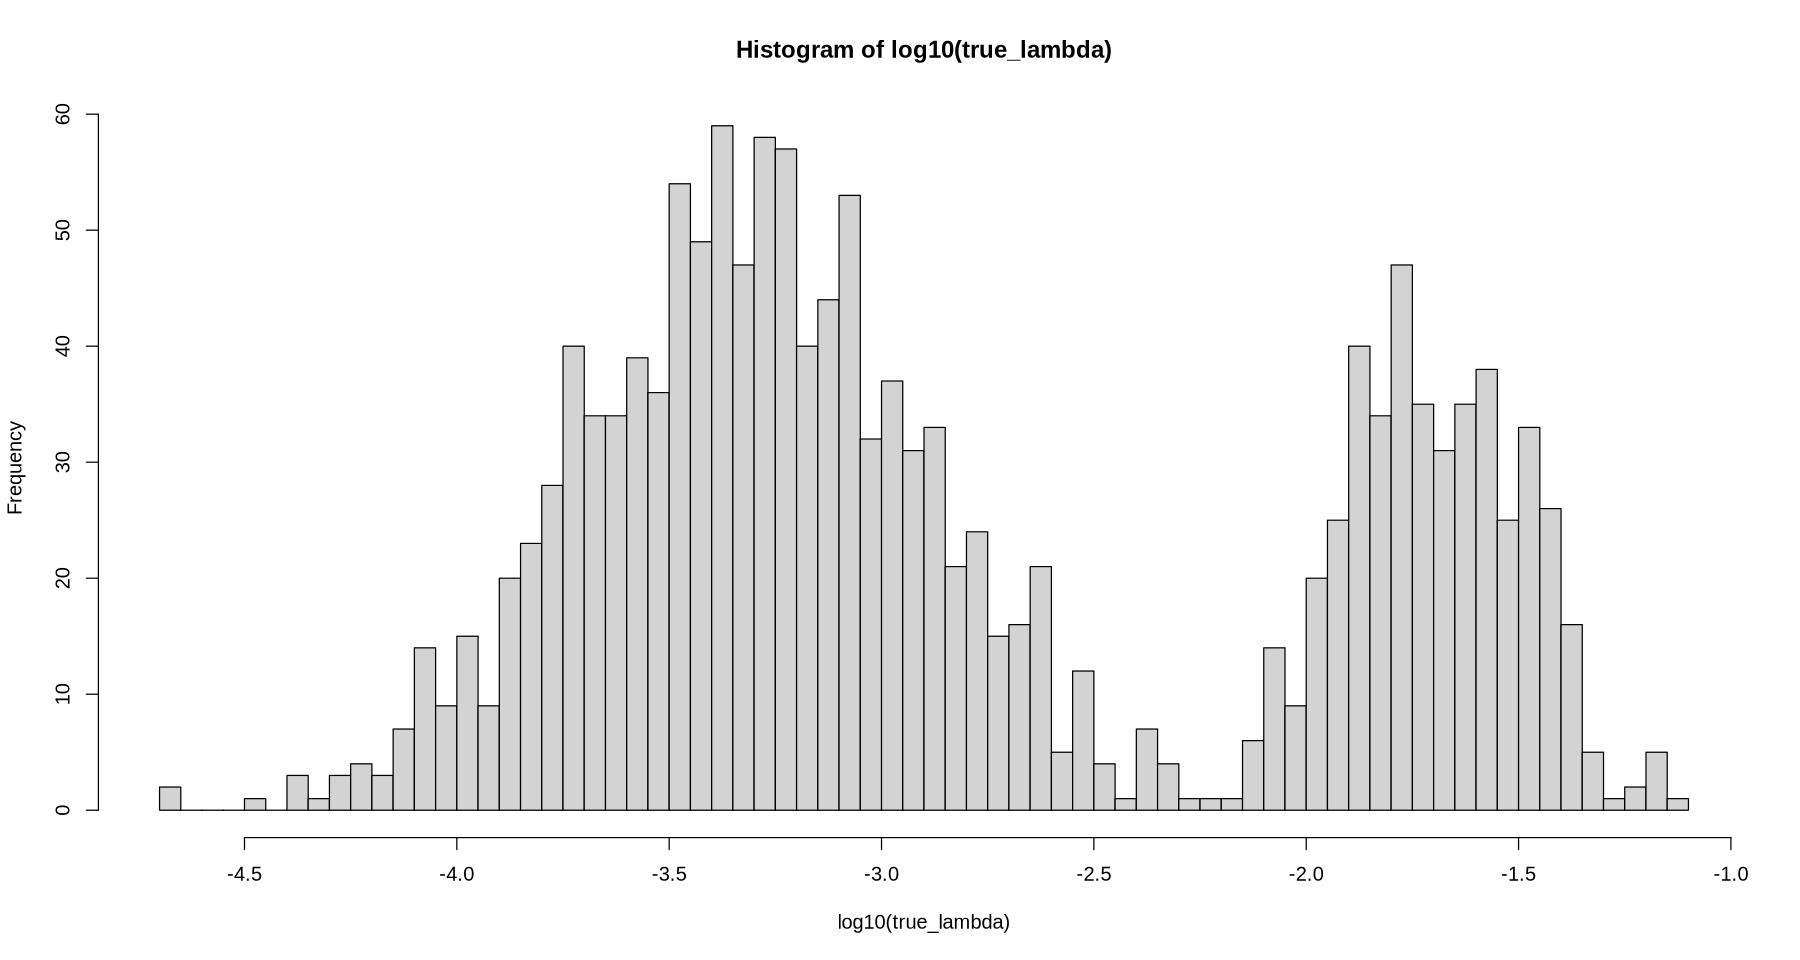

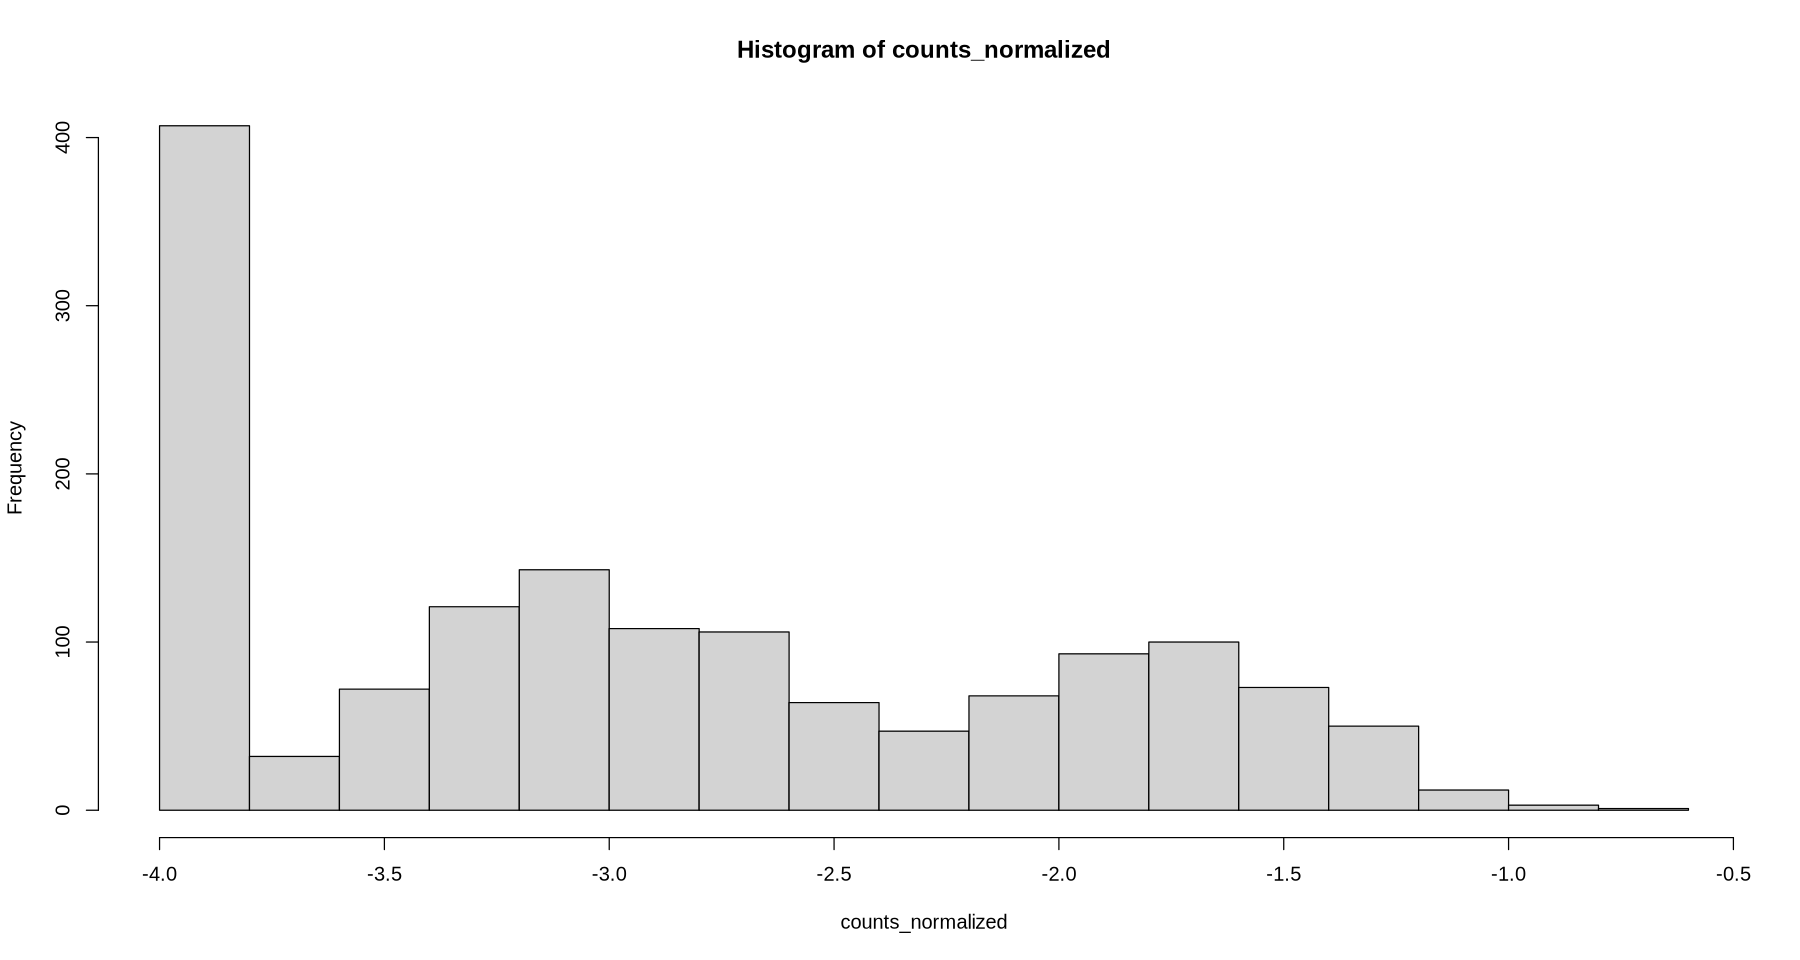

In [8]:
# Number of cells to simulate
n <- 1500

# Dispersion parameter
theta <- 3

# Get log-normally distributed total number of RNA molecules sequenced per cell (library size or sequencing depth)
# Log-normal guarantees non-negative counts and a tapering down in density for higher counts
# We first set average library size and standard deviation
mean_size <- 2500
std_size <- 0.5
sequencing_depth <- round(10^rnorm(n, log10(mean_size), std_size))
hist(log10(sequencing_depth))

# Simulate the true expression rate for each cell
mean_rate <- -3.3 # corresponds to expression rate around 10^(-3.3) = 0.0005
std_rate <- 0.4
mean_rate_2 <- -1.7
std_rate_2 <- 0.2
true_lambda <- 10^ifelse(runif(n) < .7, rnorm(n, mean_rate, std_rate), rnorm(n, mean_rate_2, std_rate_2))
hist(log10(true_lambda), 100)

# Simulate the observed read counts per cell as a poisson process
# The expected count for each cell is proportional to the true expression rate and the sequencing depth
counts <- rnbinom(n, size = theta, mu = true_lambda * sequencing_depth)
# Normalize the expression counts per cell and log-transform them
counts_normalized <- log10(counts / sequencing_depth + 1e-4)
hist(counts_normalized)


# Simulating multiple genes

## Estimate dispersion parameter

In [ ]:
adata_raw <- adata$raw$to_adata()
adata_raw <- adata_raw[, rownames(adata$var)]
adata_raw


View of AnnData object with n_obs × n_vars = 8799 × 2500
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'HTO_maxID', 'HTO_secondID', 'HTO_margin', 'HTO_classification', 'HTO_classification.global', 'hash.ID', 'cell_barcode', 'genotype', 'tissue', 'mouse', 'sample', 'hto_success', 'percent.mt', 'Sample', 'Genotype', 'Age', 'Region', 'HTO', 'batch', 'n_genes', 'doublet_score', 'predicted_doublet', 'n_counts', 'S_score', 'G2M_score', 'phase', 'age_global'
    var: 'gene_ids', 'feature_types', 'n_cells'
    uns: 'Age_colors', 'Genotype_colors', 'HTO_classification.global_colors', 'HTO_colors', 'Region_colors', 'Sample_colors', 'age_global_colors', 'batch_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'phase_colors', 'scrublet', 'umap'
    obsm: 'X_pca', 'X_umap'
    obsp: 'connectivities', 'distances'

In [ ]:
y <- adata_raw$X[, 1]
obs <- adata_raw$obs[, c("age_global", "batch", "Genotype")]
fit <- glm.nb(formula = y ~ age_global + batch + Genotype, data = obs)
fit$theta
fit$SE.theta


[1] 0.1141109

[1] 0.004406558

Warning message in glm.nb(formula = y ~ age_global + batch + Genotype, data = obs):
“alternation limit reached”
Warning message:
“glm.fit: fitted rates numerically 0 occurred”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message:
“glm.fit: algorithm did not converge”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in glm.nb(formula = y ~ age

[1] 500

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
   0.000    0.008    0.065   20.526    0.245 4415.776 

[1] 0.20047189 0.16773706 0.42928397 0.09036761 0.15050576 0.28397966

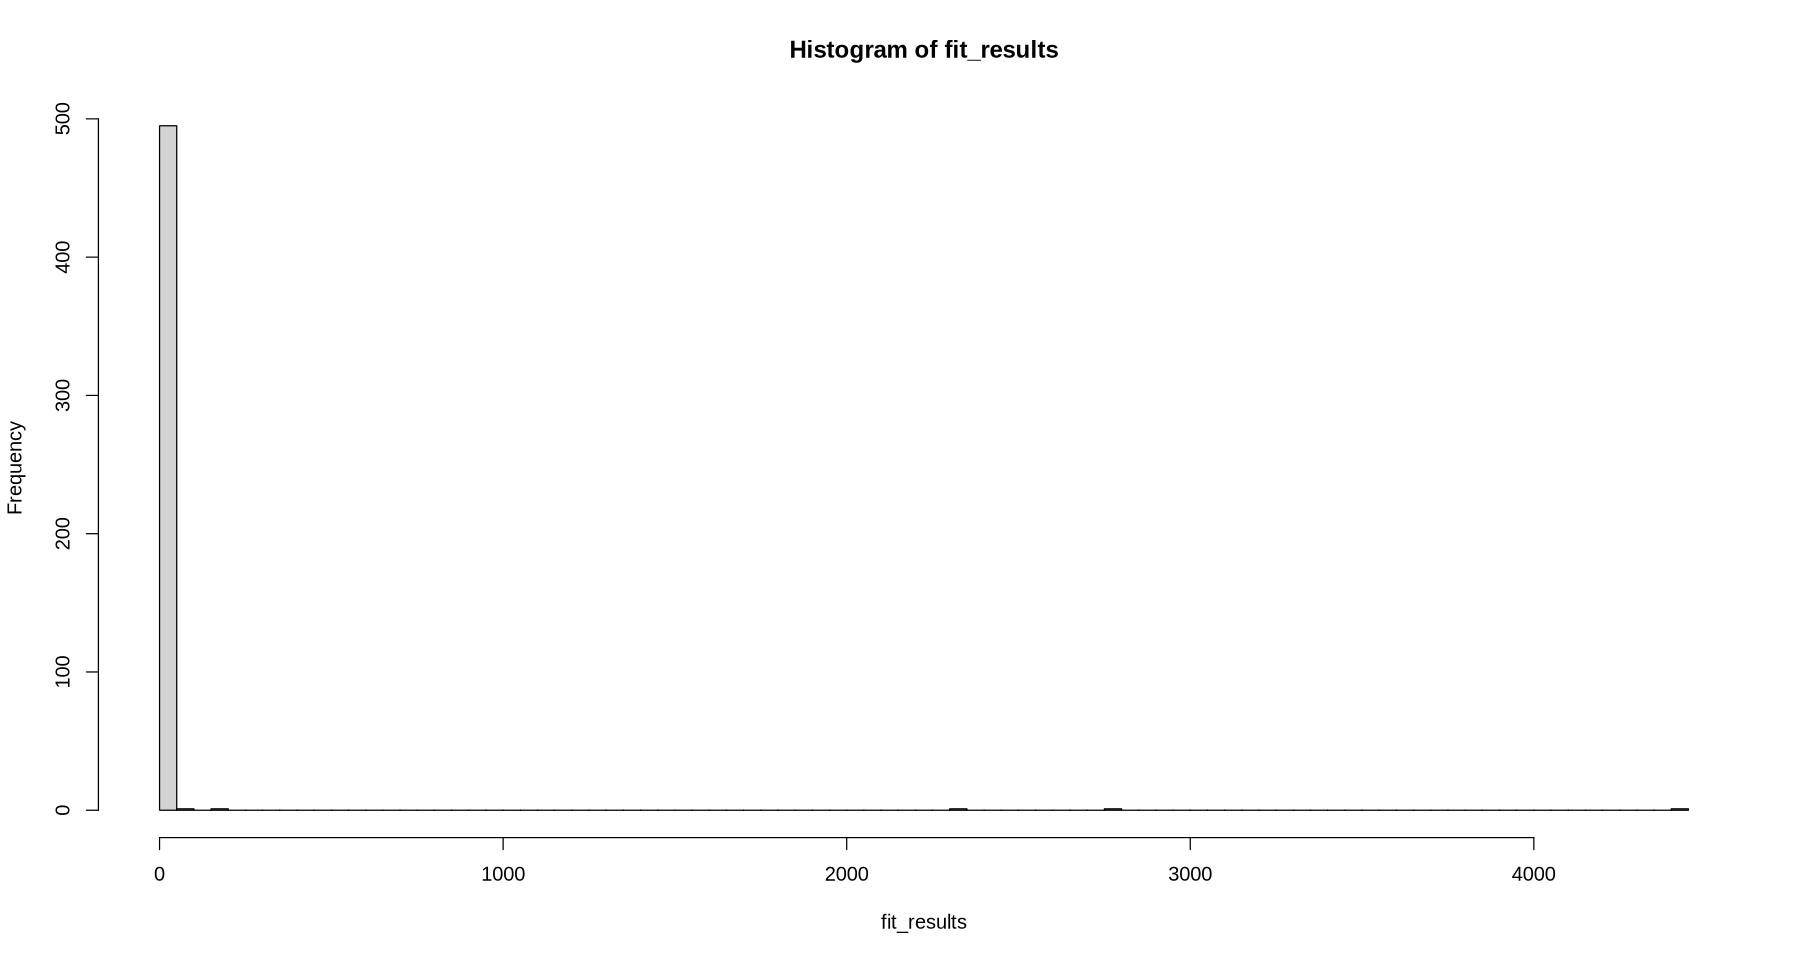

In [105]:
# THIS TAKES X MINUTES, DO NOT RUN AGAIN IF YOU DON'T NEED
# Randomly select 100 columns from adata_raw
selected_columns <- sample(1:ncol(adata_raw$X), 500)
data <- adata_raw[, selected_columns]

# Initialize an array to store the results
fit_results <- numeric(ncol(data$X))

# Loop through each gene and store the results in the array
fit_results <- pbsapply(1:ncol(data$X), function(i) {
    y <- data$X[, i]
    obs <- data$obs[, c("age_global", "batch", "Genotype")]
    fit <- glm.nb(formula = y ~ age_global + batch + Genotype, data = obs)
    return(fit$theta)
})

# The fit_results array now contains the glm.nb results for each column
length(fit_results)
summary(fit_results)
head(fit_results)
hist(fit_results, breaks = 100)


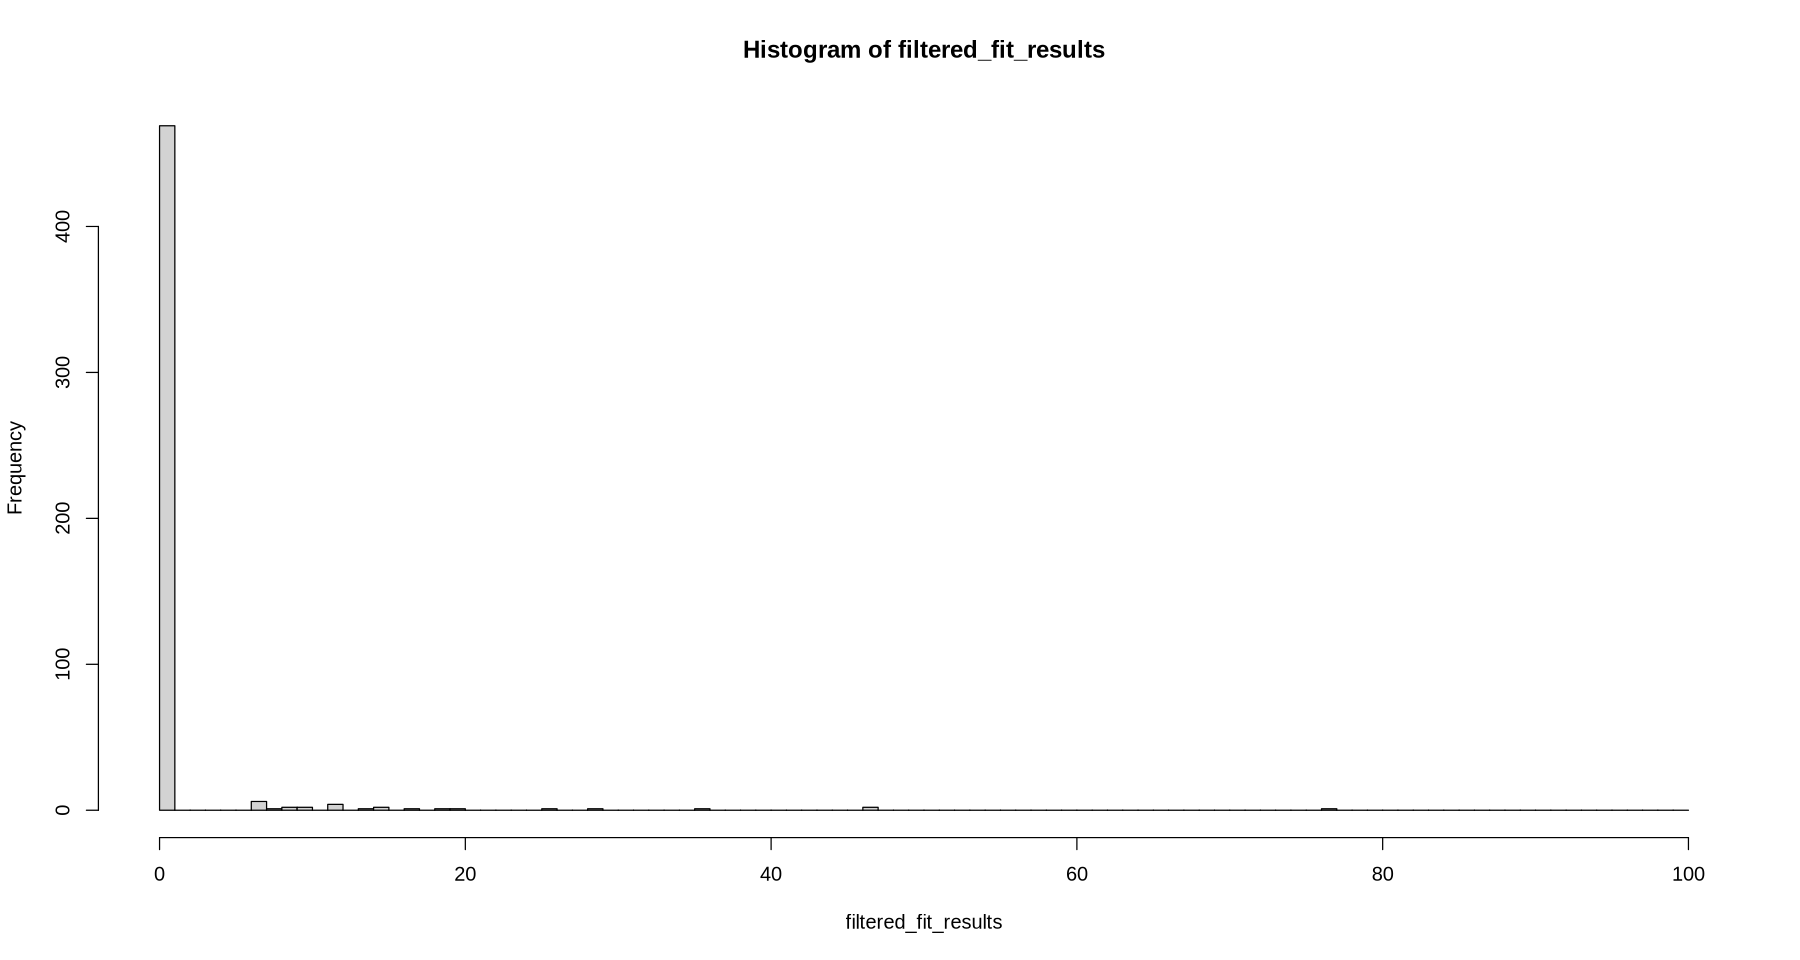

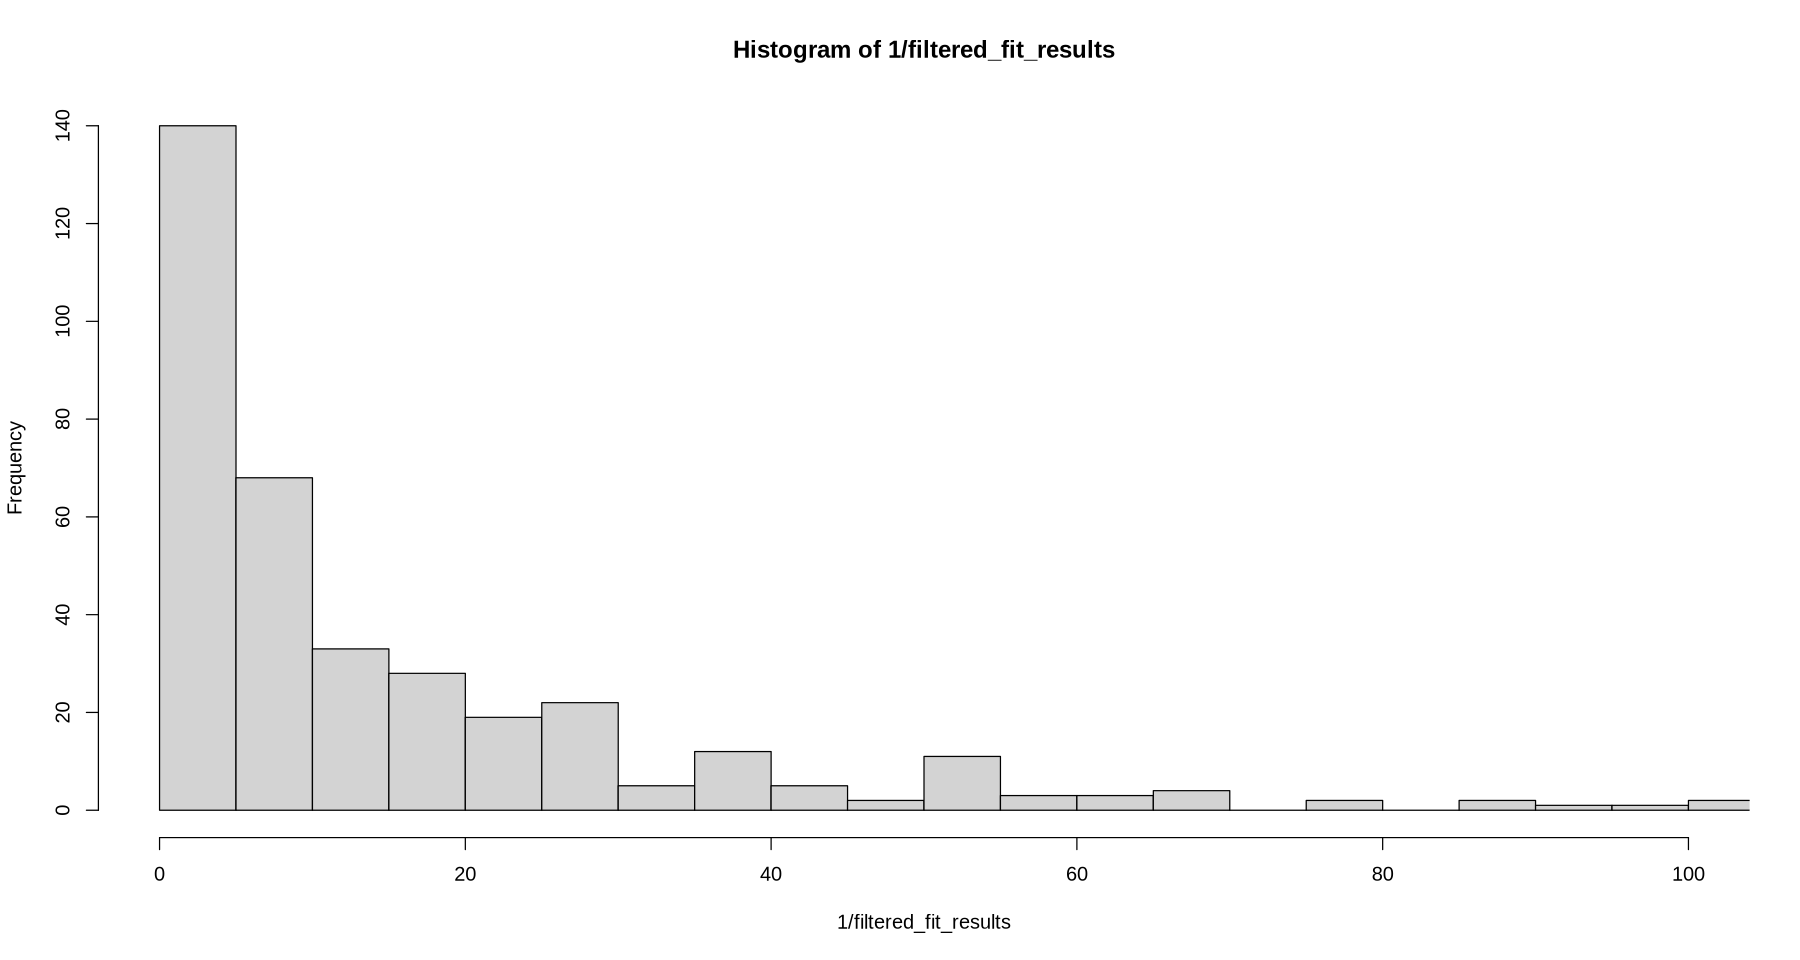

In [139]:
filtered_fit_results <- fit_results[!is.na(fit_results) & fit_results <= 100]
hist(filtered_fit_results, breaks = seq(0, 100, by = 1))
hist(1 / filtered_fit_results, breaks = seq(0, ceiling(max(1 / filtered_fit_results) / 5) * 5, by = 5), xlim = c(0, 100))


     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
    0.013     2.739    14.938   401.055    91.527 14936.670 

     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
     0.01      4.16     15.75    535.62    128.28 126840.98 

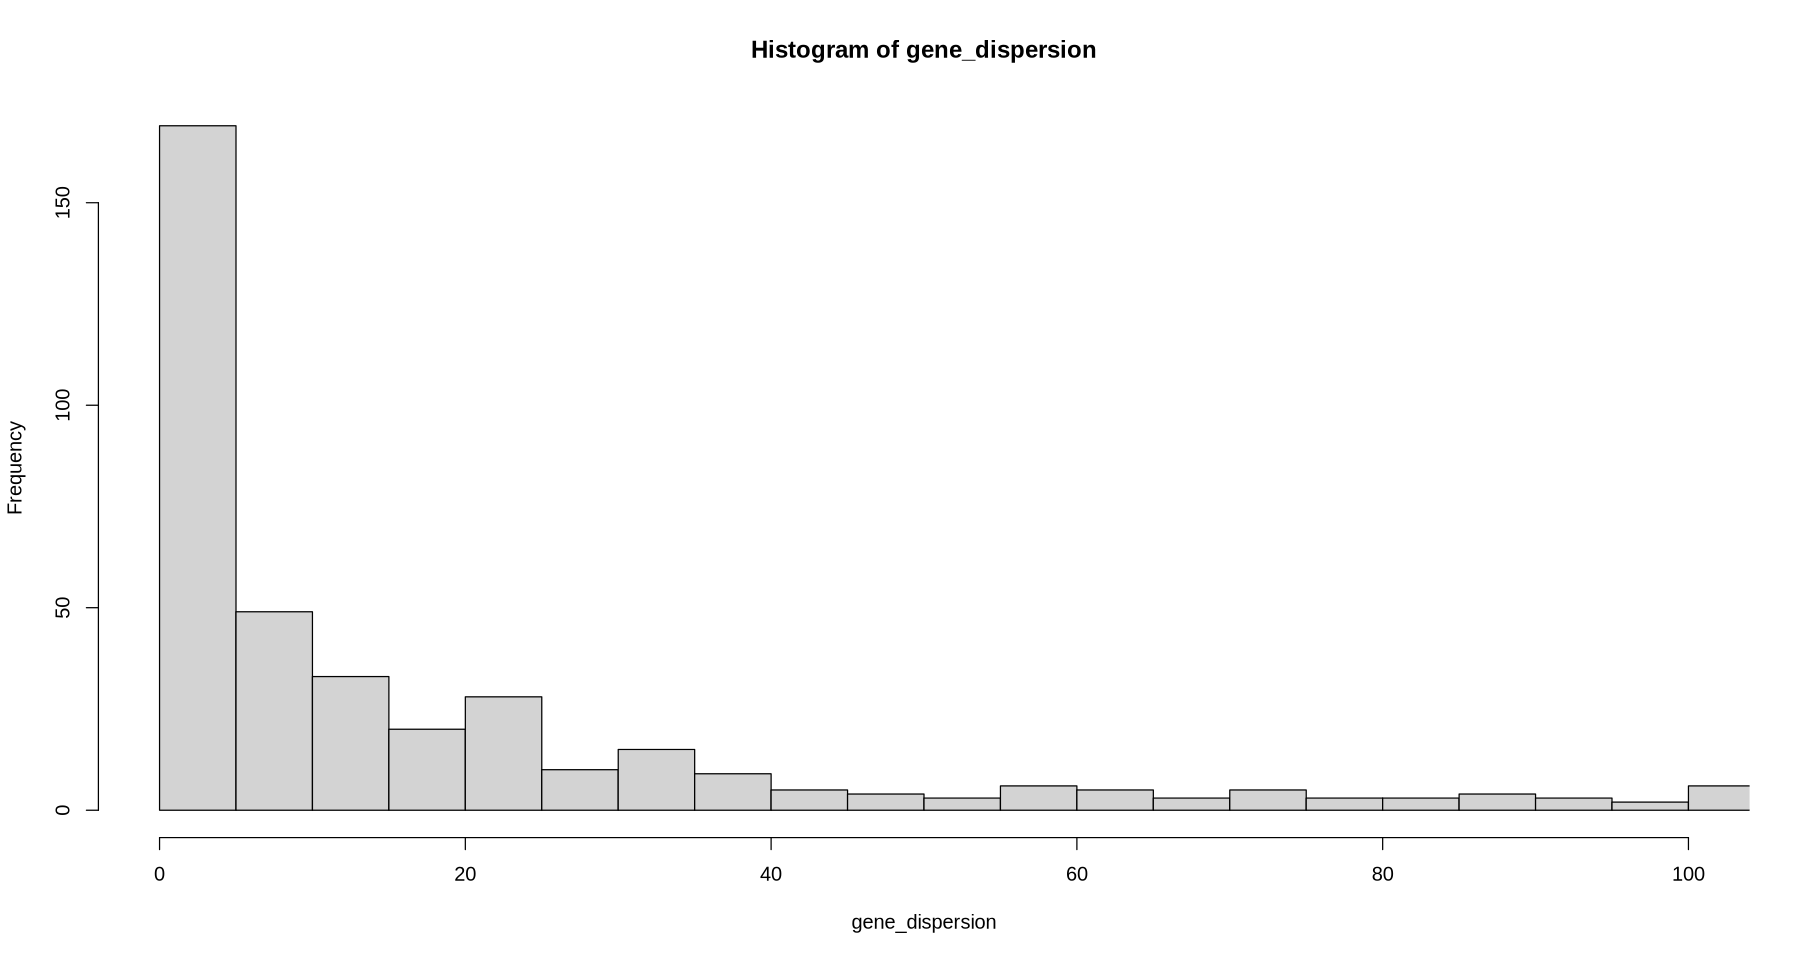

In [218]:
# Simulate a similar distribution
gene_dispersion <- 10^rnorm(500, 1.2, 1.15) # Different dispersions per gene
hist(gene_dispersion, breaks = seq(0, ceiling(max(gene_dispersion) / 5) * 5, by = 5), xlim = c(0, 100))
summary(gene_dispersion)
summary(1 / filtered_fit_results)


     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
  0.00007   0.01106   0.05592   1.51687   0.34891 128.16465 

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
 0.00001  0.00780  0.06348  1.10925  0.24018 76.29236 

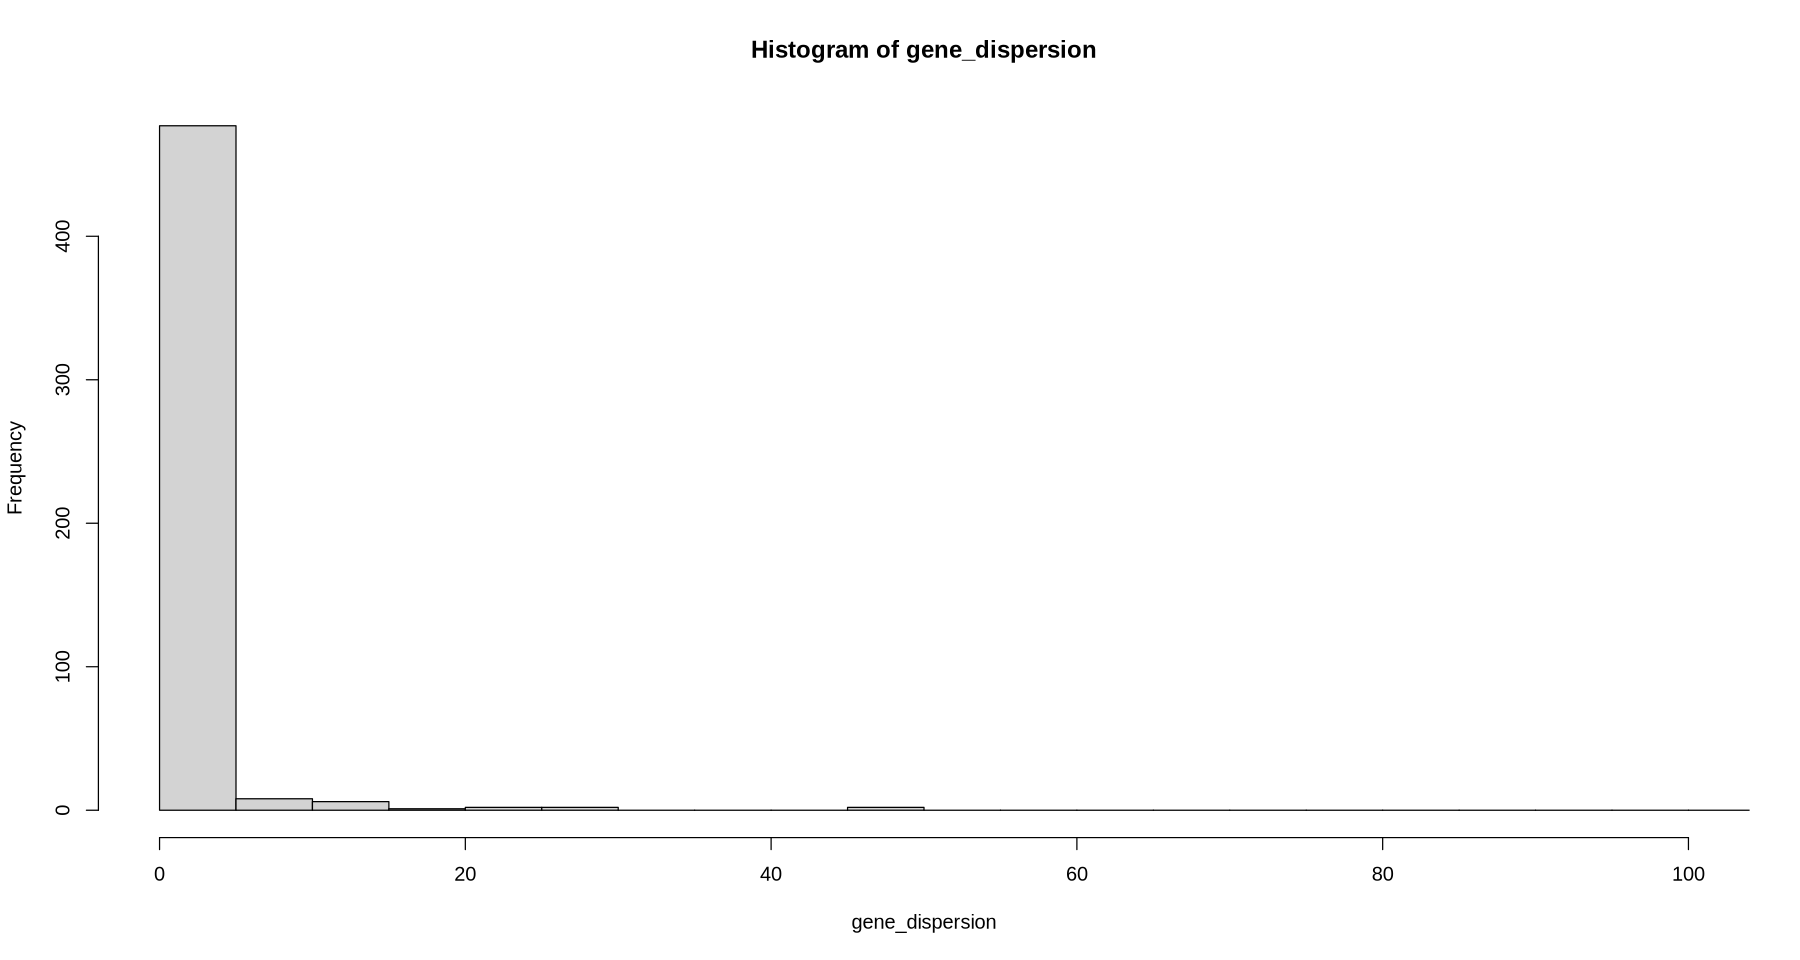

In [ ]:
# Simulate a similar distribution
gene_dispersion <- 1 / (10^rnorm(500, 1.2, 1.15)) # Different dispersions per gene
hist(gene_dispersion, breaks = seq(0, ceiling(max(gene_dispersion) / 5) * 5, by = 5), xlim = c(0, 100))
summary(gene_dispersion)
summary(filtered_fit_results)


## Unimodal data

### Poisson

### Negative binomial

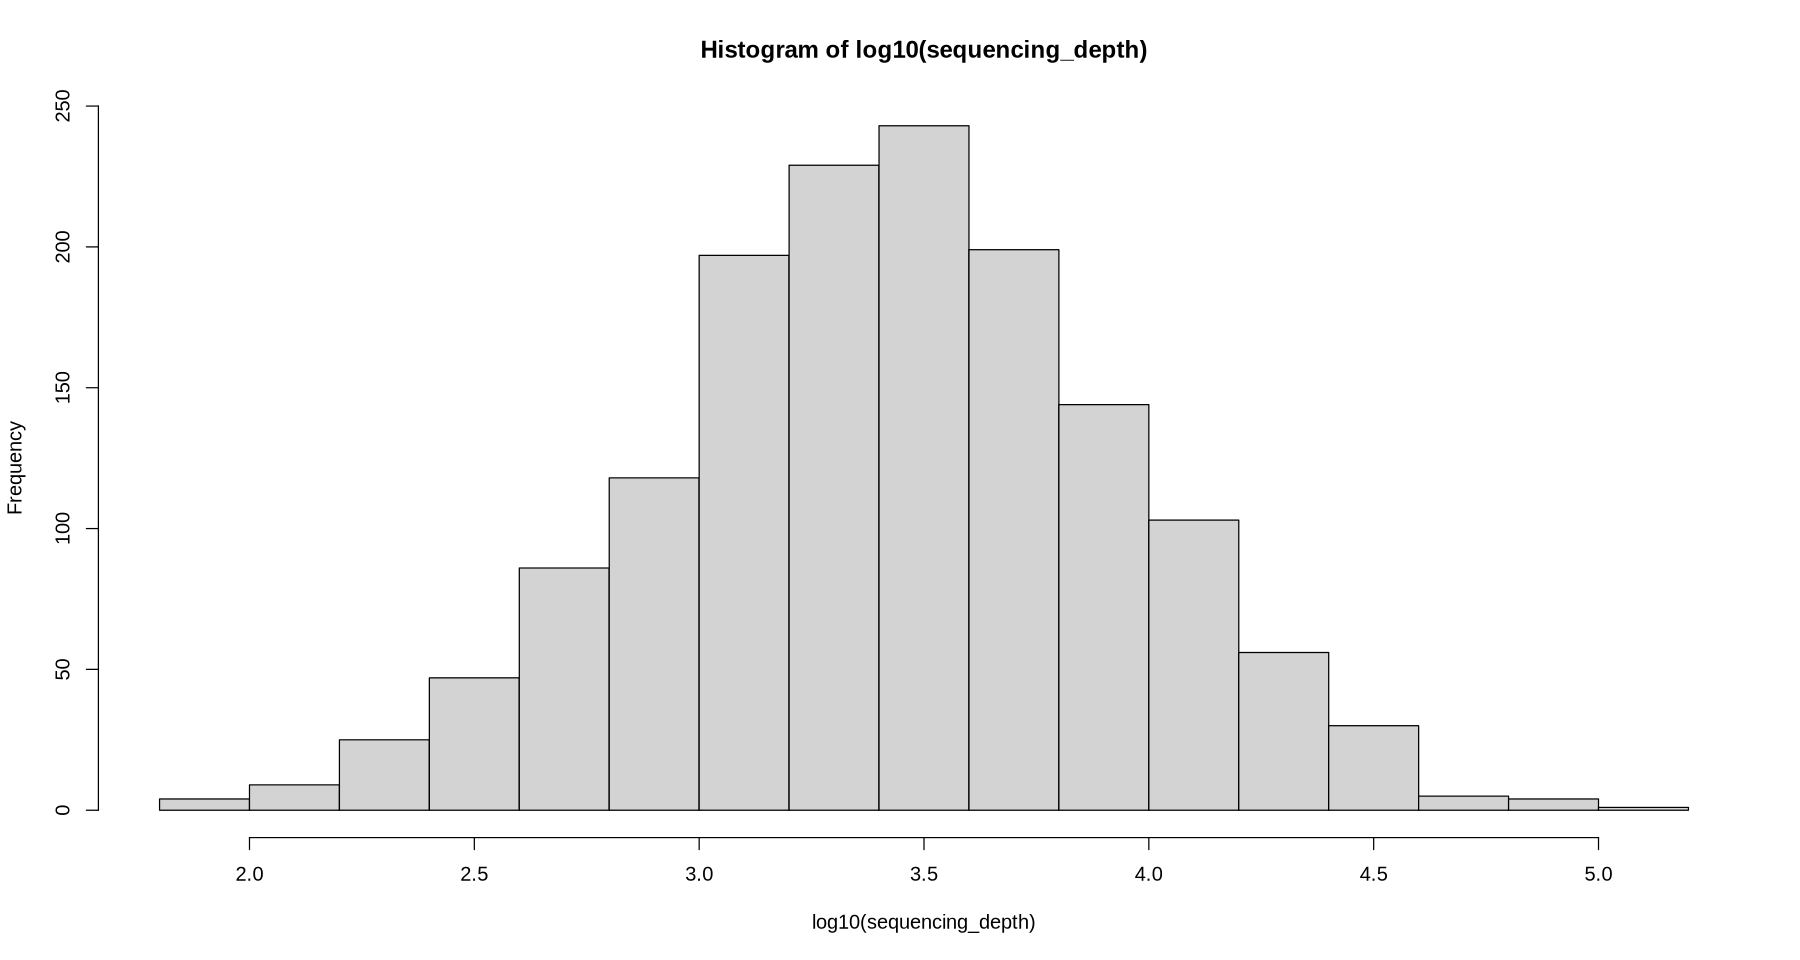

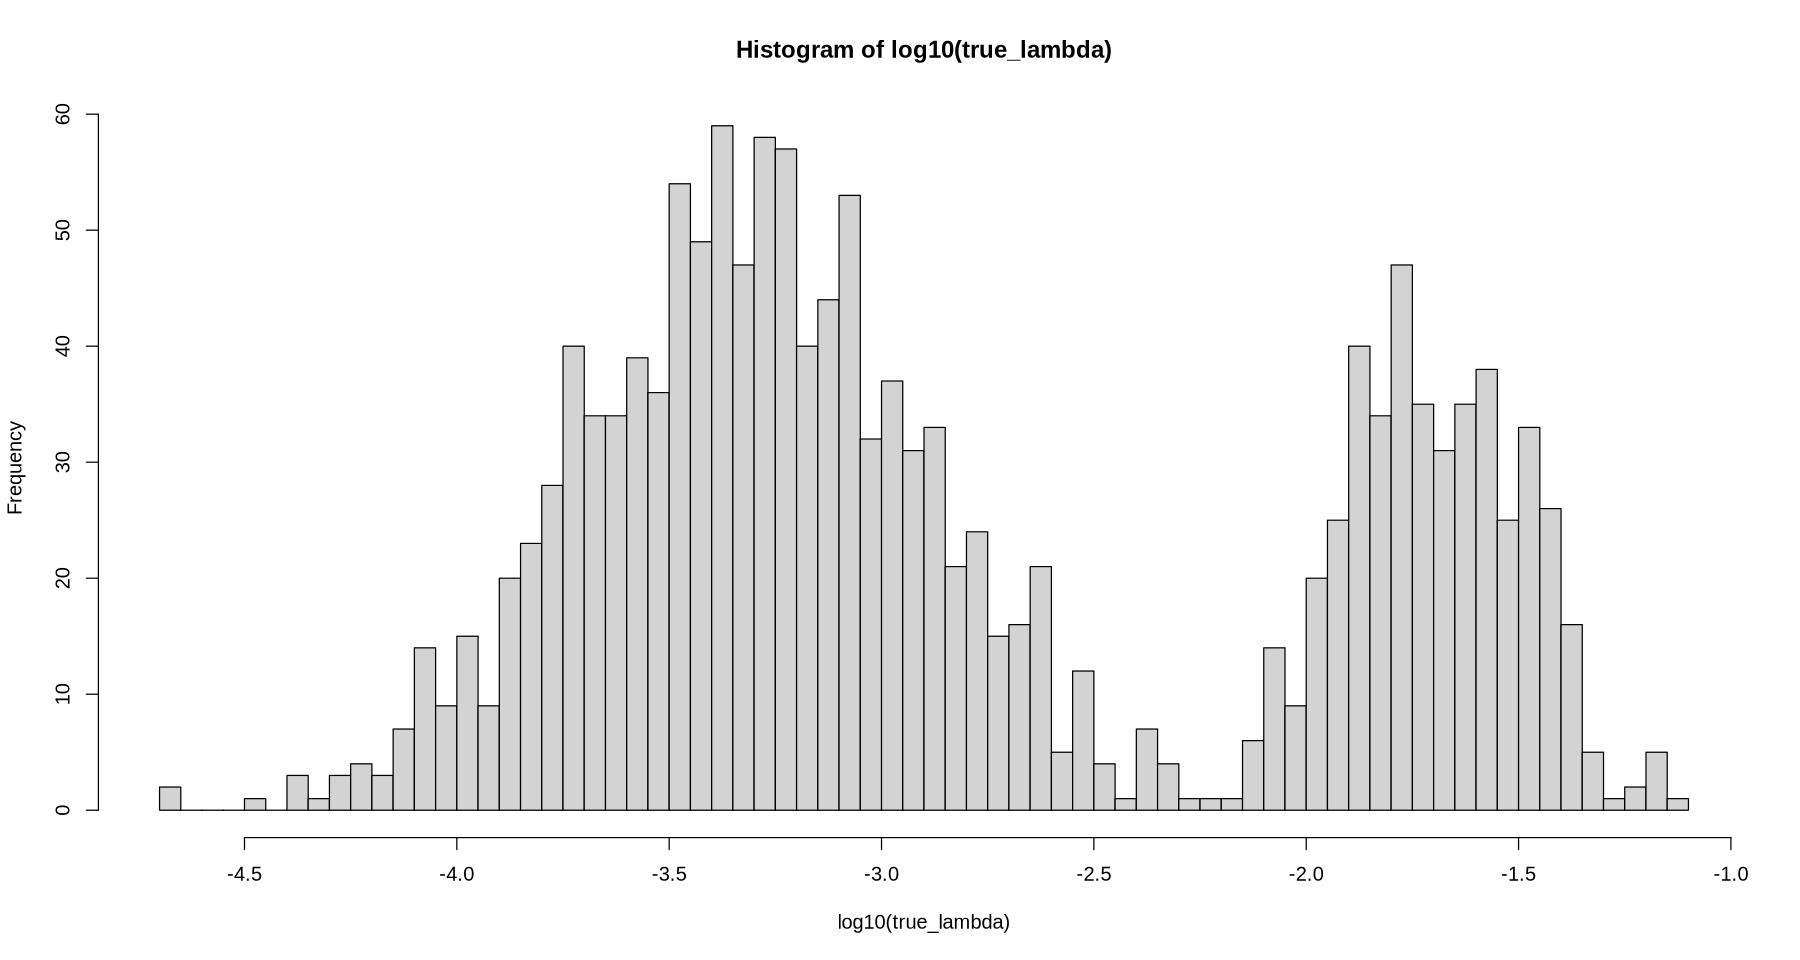

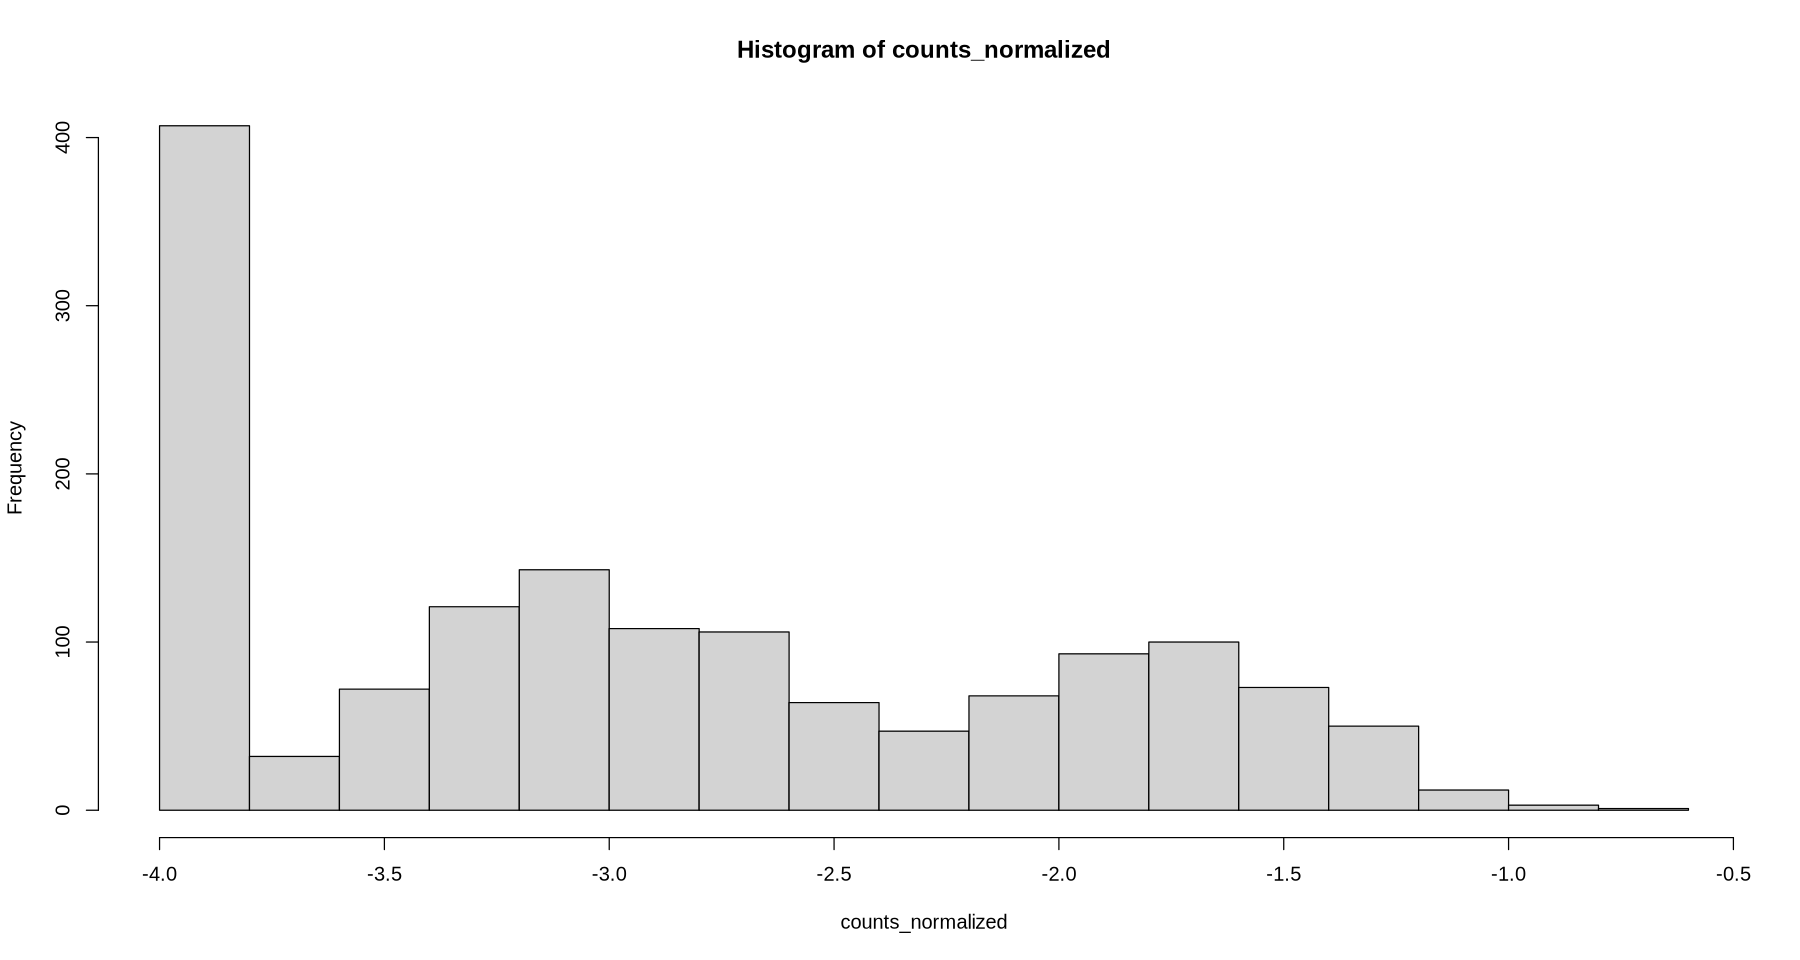

In [ ]:
# Number of genes to simulate
n_genes <- 10000

# Create gene-specific mean expressions and dispersions
gene_means <- 10^rnorm(n_genes, -3.3, .4)
gene_dispersion <- 1 / (10^rnorm(n_genes, 1.2, 1.15)) # Different dispersions per gene

# Number of cells to simulate
n_cells <- 1500

# Dispersion parameter
theta <- 3

# Get log-normally distributed total number of RNA molecules sequenced per cell (library size or sequencing depth)
# Log-normal guarantees non-negative counts and a tapering down in density for higher counts
# We first set average library size and standard deviation
mean_size <- 2500
std_size <- 0.5
sequencing_depth <- round(10^rnorm(n_cells, log10(mean_size), std_size))
hist(log10(sequencing_depth))

# Simulate the true expression rate for each cell
mean_rate <- -3.3 # corresponds to expression rate around 10^(-3.3) = 0.0005
std_rate <- 0.4
true_lambda <- 10^rnorm(n_cells, mean_rate, std_rate)
hist(log10(true_lambda), 100)

# Simulate the observed read counts per cell as a poisson process
# The expected count for each cell is proportional to the true expression rate and the sequencing depth
counts <- rnbinom(n_cells, size = theta, mu = true_lambda * sequencing_depth)
# Normalize the expression counts per cell and log-transform them
counts_normalized <- log10(counts / sequencing_depth + 1e-4)
hist(counts_normalized)
